In [2]:
import ee

ee.Authenticate()
ee.Initialize()

Enter verification code:  4/1AeoWuM-yLhliQM4GDTNLqeMZvQLYLFEpS9uHq4xyFScDoxCqncl_CDPkCes



Successfully saved authorization token.


In [27]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 237.4 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 254.8 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]
Note: you may need to restart the kernel to use updated packages.


import ee
ee.Initialize()

states = ee.FeatureCollection("TIGER/2018/States")
colorado = states.filter(ee.Filter.eq("NAME", "Colorado")).geometry()

mtbs = ee.FeatureCollection("USFS/GTAC/MTBS/burned_area_boundaries/v1")

print("MTBS properties:")
print(mtbs.first().propertyNames().getInfo())

print("Total MTBS in Colorado:")
print(mtbs.filterBounds(colorado).size().getInfo())

sample = mtbs.filterBounds(colorado).limit(5)
print(sample.getInfo())

import ee
ee.Initialize()

# ---------------------------------------------------
# Colorado boundary
# ---------------------------------------------------
states = ee.FeatureCollection("TIGER/2018/States")

colorado = states.filter(
    ee.Filter.eq("NAME", "Colorado")
).geometry()

# ---------------------------------------------------
# MTBS collection
# ---------------------------------------------------
mtbs = ee.FeatureCollection(
    "USFS/GTAC/MTBS/burned_area_boundaries/v1"
)

# ---------------------------------------------------
# Inspect fields
# ---------------------------------------------------
first = mtbs.first()

print("Property names:")
print(first.propertyNames().getInfo())

print("\nFirst feature:")
print(first.toDictionary().getInfo())

In [31]:
possible_fields = [
    "Ig_Year",
    "Fire_Year",
    "YEAR",
    "Year",
    "FIRE_YEAR",
    "Incid_Year"
]

for field in possible_fields:
    try:
        n2020 = (
            mtbs
            .filterBounds(colorado)
            .filter(ee.Filter.eq(field, 2020))
            .size()
            .getInfo()
        )

        n2019 = (
            mtbs
            .filterBounds(colorado)
            .filter(ee.Filter.eq(field, 2019))
            .size()
            .getInfo()
        )

        print(f"{field}: 2019={n2019}, 2020={n2020}")

    except Exception as e:
        print(field, "failed")

Ig_Year: 2019=0, 2020=0
Fire_Year: 2019=0, 2020=0
YEAR: 2019=0, 2020=0
Year: 2019=0, 2020=0
FIRE_YEAR: 2019=0, 2020=0
Incid_Year: 2019=0, 2020=0


# Getting data from GEE

import ee
import geemap
import pandas as pd

ee.Initialize()

# --------------------------------------------------
# Parameters
# --------------------------------------------------
FIRE_YEAR = 2020
BEFORE_YEAR = 2019
AFTER_YEAR = 2021
N_FIRES = 20
OUT_CSV = f"CO_{FIRE_YEAR}_MTBS_{N_FIRES}_AEF_GRIDMET_training_table.csv"

# --------------------------------------------------
# Colorado boundary
# --------------------------------------------------
states = ee.FeatureCollection("TIGER/2018/States")
colorado = states.filter(ee.Filter.eq("NAME", "Colorado")).geometry()

# --------------------------------------------------
# MTBS fire perimeters
# --------------------------------------------------
mtbs = ee.FeatureCollection("USFS/GTAC/MTBS/burned_area_boundaries/v1")

print("MTBS property names:")
print(mtbs.first().propertyNames().getInfo())

FIRE_DATE_FIELD = "Ig_Date"

# --------------------------------------------------
# Add fire year from Ig_Date
# --------------------------------------------------
def add_fire_year_from_date(f):
    fire_date = ee.Date(f.get(FIRE_DATE_FIELD))

    return f.set({
        "fire_date": fire_date.format("YYYY-MM-dd"),
        "fire_year_from_date": fire_date.get("year")
    })

mtbs_with_year = mtbs.map(add_fire_year_from_date)

# --------------------------------------------------
# Filter Colorado 2020 fires
# --------------------------------------------------
fires = (
    mtbs_with_year
    .filterBounds(colorado)
    .filter(ee.Filter.eq("fire_year_from_date", FIRE_YEAR))
    .limit(N_FIRES)
)

print("Number of selected Colorado 2020 fires:")
print(fires.size().getInfo())

print("First selected fire:")
print(fires.first().toDictionary().getInfo())

# --------------------------------------------------
# Add area and centroid
# --------------------------------------------------
def add_area(f):
    area_ha = f.geometry().area(maxError=30).divide(10000)
    centroid = f.geometry().centroid(maxError=30).coordinates()

    return f.set({
        "event_id": ee.String("fire_").cat(ee.String(f.id())),
        "fire_year": FIRE_YEAR,
        "burn_area_ha": area_ha,
        "lon": centroid.get(0),
        "lat": centroid.get(1)
    })

fires = fires.map(add_area)

# --------------------------------------------------
# AEF / Satellite Embeddings
# --------------------------------------------------
emb = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")

emb_before_raw = emb.filterDate(
    f"{BEFORE_YEAR}-01-01",
    f"{BEFORE_YEAR}-12-31"
).first()

emb_after_raw = emb.filterDate(
    f"{AFTER_YEAR}-01-01",
    f"{AFTER_YEAR}-12-31"
).first()

# Force safe projection for Colorado extraction
emb_before = (
    emb_before_raw
    .resample("bilinear")
    .reproject(crs="EPSG:4326", scale=30)
)

emb_after = (
    emb_after_raw
    .resample("bilinear")
    .reproject(crs="EPSG:4326", scale=30)
)

bands = emb_before.bandNames()

before = emb_before.rename(
    bands.map(lambda b: ee.String("before_").cat(ee.String(b)))
)

after = emb_after.rename(
    bands.map(lambda b: ee.String("after_").cat(ee.String(b)))
)

delta = emb_after.subtract(emb_before).rename(
    bands.map(lambda b: ee.String("delta_").cat(ee.String(b)))
)

embedding_stack = (
    before
    .addBands(after)
    .addBands(delta)
    .reproject(crs="EPSG:4326", scale=30)
)

# --------------------------------------------------
# gridMET fire-weather extraction
# --------------------------------------------------
gridmet = ee.ImageCollection("IDAHO_EPSCOR/GRIDMET")

def add_fire_weather(f):
    fire_date = ee.Date(f.get(FIRE_DATE_FIELD))

    window = gridmet.filterDate(
        fire_date.advance(-3, "day"),
        fire_date.advance(4, "day")
    )

    vpd_day = (
        gridmet
        .filterDate(fire_date, fire_date.advance(1, "day"))
        .select("vpd")
        .mean()
    )

    vpd7 = window.select("vpd").mean()
    tmax7 = window.select("tmmx").mean()
    pr7 = window.select("pr").sum()

    def zonal_mean(img, band):
        return img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=f.geometry(),
            scale=4000,
            crs="EPSG:4326",
            maxPixels=1e9,
            bestEffort=True,
            tileScale=4
        ).get(band)

    return f.set({
        "vpd_fire_day": zonal_mean(vpd_day, "vpd"),
        "vpd_7day": zonal_mean(vpd7, "vpd"),
        "tmmx_7day": zonal_mean(tmax7, "tmmx"),
        "pr_7day": zonal_mean(pr7, "pr")
    })

fires = fires.map(add_fire_weather)

# --------------------------------------------------
# Extract mean embeddings over fire polygons
# --------------------------------------------------
training = embedding_stack.reduceRegions(
    collection=fires,
    reducer=ee.Reducer.mean(),
    scale=30,
    crs="EPSG:4326",
    tileScale=8
)

# --------------------------------------------------
# Export directly to CSV
# --------------------------------------------------
geemap.ee_to_csv(training, OUT_CSV)

print(f"Saved: {OUT_CSV}")

In [11]:
df = pd.read_csv("CO_2020_MTBS_20_AEF_GRIDMET_training_table.csv")

print(df.columns.tolist())

['Asmnt_Type', 'BurnBndAc', 'BurnBndLat', 'BurnBndLon', 'Comment', 'Event_ID', 'High_T', 'Ig_Date', 'IncGreen_T', 'Incid_Name', 'Incid_Type', 'Low_T', 'Map_ID', 'Map_Prog', 'Mod_T', 'NoData_T', 'Perim_ID', 'Post_ID', 'Pre_ID', 'burn_area_ha', 'dNBR_offst', 'dNBR_stdDv', 'event_id', 'fire_date', 'fire_year', 'fire_year_from_date', 'irwinID', 'lat', 'lon', 'pr_7day', 'tmmx_7day', 'vpd_7day', 'vpd_fire_day']


import ee
import geemap
import pandas as pd

ee.Initialize()

# --------------------------------------------------
# Parameters
# --------------------------------------------------
FIRE_YEAR = 2020
BEFORE_YEAR = 2019
AFTER_YEAR = 2021
N_FIRES = 20
BUFFER_M = 1000

OUT_CSV = f"CO_{FIRE_YEAR}_MTBS_{N_FIRES}_AEF_GRIDMET_BUFFER_training_table.csv"

# --------------------------------------------------
# Colorado and MTBS
# --------------------------------------------------
states = ee.FeatureCollection("TIGER/2018/States")
colorado = states.filter(ee.Filter.eq("NAME", "Colorado")).geometry()

mtbs = ee.FeatureCollection("USFS/GTAC/MTBS/burned_area_boundaries/v1")

FIRE_DATE_FIELD = "Ig_Date"

print("MTBS properties:")
print(mtbs.first().propertyNames().getInfo())

# --------------------------------------------------
# Add fire year from Ig_Date
# --------------------------------------------------
def add_fire_year_from_date(f):
    fire_date = ee.Date(f.get(FIRE_DATE_FIELD))

    return f.set({
        "fire_date": fire_date.format("YYYY-MM-dd"),
        "fire_year_from_date": fire_date.get("year")
    })

mtbs_with_year = mtbs.map(add_fire_year_from_date)

# --------------------------------------------------
# Filter Colorado 2020 fires
# --------------------------------------------------
fires_raw = (
    mtbs_with_year
    .filterBounds(colorado)
    .filter(ee.Filter.eq("fire_year_from_date", FIRE_YEAR))
    .limit(N_FIRES)
)

print("Selected Colorado 2020 fires:")
print(fires_raw.size().getInfo())

print("First selected fire:")
print(fires_raw.first().toDictionary().getInfo())

# --------------------------------------------------
# Convert MTBS polygons to clean centroid buffers
# --------------------------------------------------
def make_centroid_buffer(f):
    fire_date = ee.Date(f.get(FIRE_DATE_FIELD))

    lon = ee.Number.parse(f.get("BurnBndLon"))
    lat = ee.Number.parse(f.get("BurnBndLat"))

    point = ee.Geometry.Point([lon, lat])
    buffer_geom = point.buffer(BUFFER_M)

    # BurnBndAc is acres, convert to hectares
    burn_area_ha = ee.Number(f.get("BurnBndAc")).multiply(0.404686)

    return ee.Feature(buffer_geom).copyProperties(f).set({
        "event_id": ee.String("fire_").cat(ee.String(f.id())),
        "fire_year": FIRE_YEAR,
        "fire_date": fire_date.format("YYYY-MM-dd"),
        "burn_area_ha": burn_area_ha,
        "lon": lon,
        "lat": lat,
        "buffer_m": BUFFER_M
    })

fires = fires_raw.map(make_centroid_buffer)

# --------------------------------------------------
# gridMET weather extraction
# --------------------------------------------------
gridmet = ee.ImageCollection("IDAHO_EPSCOR/GRIDMET")

def add_fire_weather(f):
    fire_date = ee.Date(f.get(FIRE_DATE_FIELD))

    window = gridmet.filterDate(
        fire_date.advance(-3, "day"),
        fire_date.advance(4, "day")
    )

    vpd_day = (
        gridmet
        .filterDate(fire_date, fire_date.advance(1, "day"))
        .select("vpd")
        .mean()
    )

    vpd7 = window.select("vpd").mean()
    tmax7 = window.select("tmmx").mean()
    pr7 = window.select("pr").sum()

    def zonal_mean(img, band):
        return img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=f.geometry(),
            scale=4000,
            maxPixels=1e9,
            bestEffort=True,
            tileScale=4
        ).get(band)

    return f.set({
        "vpd_fire_day": zonal_mean(vpd_day, "vpd"),
        "vpd_7day": zonal_mean(vpd7, "vpd"),
        "tmmx_7day": zonal_mean(tmax7, "tmmx"),
        "pr_7day": zonal_mean(pr7, "pr")
    })

fires = fires.map(add_fire_weather)

# --------------------------------------------------
# AEF / Satellite Embeddings
# --------------------------------------------------
emb = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")

emb_before = emb.filterDate(
    f"{BEFORE_YEAR}-01-01",
    f"{BEFORE_YEAR}-12-31"
).first()

emb_after = emb.filterDate(
    f"{AFTER_YEAR}-01-01",
    f"{AFTER_YEAR}-12-31"
).first()

print("Before embedding band count:")
print(emb_before.bandNames().size().getInfo())

print("Before embedding first 10 bands:")
print(emb_before.bandNames().slice(0, 10).getInfo())

bands = emb_before.bandNames()

before = emb_before.select(
    bands,
    bands.map(lambda b: ee.String("before_").cat(ee.String(b)))
)

after = emb_after.select(
    bands,
    bands.map(lambda b: ee.String("after_").cat(ee.String(b)))
)

delta = emb_after.subtract(emb_before).select(
    bands,
    bands.map(lambda b: ee.String("delta_").cat(ee.String(b)))
)

embedding_stack = before.addBands(after).addBands(delta)

print("Embedding stack band count:")
print(embedding_stack.bandNames().size().getInfo())

print("Embedding stack first 10 bands:")
print(embedding_stack.bandNames().slice(0, 10).getInfo())

# --------------------------------------------------
# Test embedding extraction on first centroid buffer
# --------------------------------------------------
test_extract = embedding_stack.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=fires.first().geometry(),
    scale=100,
    maxPixels=1e9,
    bestEffort=True,
    tileScale=16
)

test_dict = test_extract.getInfo()

print("Test extraction first keys:")
print(list(test_dict.keys())[:20])

print("Number of extracted embedding values:")
print(len(test_dict))

if len(test_dict) == 0:
    raise ValueError("Embedding extraction failed. Try larger BUFFER_M or different scale.")

# --------------------------------------------------
# Extract embeddings for all fires
# --------------------------------------------------
training = embedding_stack.reduceRegions(
    collection=fires,
    reducer=ee.Reducer.mean(),
    scale=100,
    tileScale=16
)

# --------------------------------------------------
# Check output before export
# --------------------------------------------------
first_out = training.first().toDictionary().getInfo()

embedding_out_cols = [
    k for k in first_out.keys()
    if k.startswith("before_") or k.startswith("after_") or k.startswith("delta_")
]

print("Number of embedding columns in first output:")
print(len(embedding_out_cols))

print("First 10 embedding output columns:")
print(embedding_out_cols[:10])

if len(embedding_out_cols) == 0:
    raise ValueError("No embedding columns in output.")

# --------------------------------------------------
# Export local CSV
# --------------------------------------------------
geemap.ee_to_csv(training, OUT_CSV)

print(f"Saved: {OUT_CSV}")

# --------------------------------------------------
# Verify local CSV
# --------------------------------------------------
df_check = pd.read_csv(OUT_CSV)

embedding_cols_local = [
    c for c in df_check.columns
    if c.startswith("before_") or c.startswith("after_") or c.startswith("delta_")
]

print("Local CSV shape:", df_check.shape)
print("Embedding columns in local CSV:", len(embedding_cols_local))
print("First 10 embedding columns:")
print(embedding_cols_local[:10])

In [24]:
# ============================================================
# FULL WORKFLOW:
# MTBS fire/non-fire labeled points + topography + climate/VPD
# + embedding pre-fire/post-fire summaries for XGBoost
# ============================================================

import ee
import pandas as pd
import os

ee.Initialize()

# ============================================================
# 0. SETTINGS
# ============================================================

SAFE_CRS = "EPSG:4326"
SCALE = 100
SEED = 42

START_YEAR = 2000
END_YEAR = 2023
N_FIRES = 20

NONFIRE_BUFFER_M = 1135   # approx. 1000-acre radius
INNER_BUFFER_M = 200      # avoid placing non-fire too close to fire center

OUT_CSV = "xgboost_fire_nonfire_climate_topo_embedding.csv"


# ============================================================
# 1. STUDY AREA
# ============================================================

states = ee.FeatureCollection("TIGER/2018/States")

study_area = states.filter(
    ee.Filter.eq("NAME", "Colorado")
).geometry()


# ============================================================
# 2. LOAD AND FILTER MTBS
# ============================================================

mtbs_all = ee.FeatureCollection(
    "USFS/GTAC/MTBS/burned_area_boundaries/v1"
)

mtbs_bounds = mtbs_all.filterBounds(study_area)

print("MTBS in study area:", mtbs_bounds.size().getInfo())


def clean_fire(f):
    fire_year = ee.Date(f.get("Ig_Date")).get("year")

    geom = (
        f.geometry()
        .transform(SAFE_CRS, 1)
        .buffer(0, 1)
        .simplify(30)
    )

    return ee.Feature(geom, {
        "fire_id": f.get("Event_ID"),
        "fire_name": f.get("Incid_Name"),
        "fire_year": fire_year
    })


fires_clean_all = mtbs_bounds.map(clean_fire)

fires_clean = (
    fires_clean_all
    .filter(ee.Filter.gte("fire_year", START_YEAR))
    .filter(ee.Filter.lte("fire_year", END_YEAR))
    .randomColumn("rand", SEED)
    .sort("rand")
    .limit(N_FIRES)
)

print("Selected fires:", fires_clean.size().getInfo())


# ============================================================
# 3. CREATE FIRE POINTS
# label = 1
# Uses centroid to avoid random-point failure inside invalid polygons
# ============================================================

def make_fire_point(f):
    pt = f.geometry().centroid(30)

    return ee.Feature(pt, {
        "fire_id": f.get("fire_id"),
        "fire_name": f.get("fire_name"),
        "fire_year": f.get("fire_year"),
        "label": 1,
        "sample_type": "fire"
    })


fire_points = fires_clean.map(make_fire_point)

print("Fire points:", fire_points.size().getInfo())


# ============================================================
# 4. CREATE NON-FIRE POINTS
# label = 0
# Safer method: make a nearby point from centroid offset
# This avoids randomPoints failing on empty ring geometries.
# ============================================================

def make_nonfire_point(f):
    center = f.geometry().centroid(30)

    # Make deterministic offset point near the fire.
    # 0.02 degrees is roughly 2 km, enough for nearby non-fire.
    coords = center.coordinates()
    lon = ee.Number(coords.get(0))
    lat = ee.Number(coords.get(1))

    nonfire_geom = ee.Geometry.Point([
        lon.add(0.02),
        lat.add(0.02)
    ])

    # If shifted point falls outside study area, use opposite direction
    alt_geom = ee.Geometry.Point([
        lon.subtract(0.02),
        lat.subtract(0.02)
    ])

    nonfire_geom = ee.Algorithms.If(
        study_area.contains(nonfire_geom, 30),
        nonfire_geom,
        alt_geom
    )

    return ee.Feature(ee.Geometry(nonfire_geom), {
        "fire_id": f.get("fire_id"),
        "fire_name": f.get("fire_name"),
        "fire_year": f.get("fire_year"),
        "label": 0,
        "sample_type": "non_fire"
    })


nonfire_points = fires_clean.map(make_nonfire_point)

print("Non-fire points:", nonfire_points.size().getInfo())


# ============================================================
# 5. COMBINE POINTS
# ============================================================

samples = fire_points.merge(nonfire_points)

print("Total sample points:", samples.size().getInfo())


# ============================================================
# 6. TOPOGRAPHY PREDICTORS
# ============================================================

dem = ee.Image("USGS/SRTMGL1_003").select("elevation").rename("elevation")
slope = ee.Terrain.slope(dem).rename("slope")
aspect = ee.Terrain.aspect(dem).rename("aspect")

topo_img = dem.addBands(slope).addBands(aspect)


# ============================================================
# 7. CLIMATE / VPD PREDICTORS
# TerraClimate monthly
# Units:
# tmmx/tmmn are temperature * 0.1 C
# vpd is vapor pressure deficit * 0.01 kPa
# ppt is mm
# ============================================================

terraclimate = ee.ImageCollection("IDAHO_EPSCOR/TERRACLIMATE")


def climate_for_year(year, prefix):
    year = ee.Number(year)

    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, "year")

    col = terraclimate.filterDate(start, end)

    ppt = col.select("pr").sum().rename(prefix + "_ppt_sum")

    tmax = col.select("tmmx").mean().multiply(0.1).rename(prefix + "_tmax_mean")
    tmin = col.select("tmmn").mean().multiply(0.1).rename(prefix + "_tmin_mean")

    vpd = col.select("vpd").mean().multiply(0.01).rename(prefix + "_vpd_mean")

    return ppt.addBands(tmax).addBands(tmin).addBands(vpd)


# ============================================================
# 8. EMBEDDING PREDICTORS
# Replace collection name if needed.
# This assumes your embedding image collection has many bands.
# ============================================================

embedding_ic = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")


def rename_embedding(img, prefix):
    old_names = img.bandNames()

    new_names = old_names.map(
        lambda b: ee.String(prefix).cat("_").cat(ee.String(b))
    )

    return img.rename(new_names)


def embedding_for_year(year, prefix):
    year = ee.Number(year)

    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, "year")

    img = (
        embedding_ic
        .filterDate(start, end)
        .filterBounds(study_area)
        .mosaic()
        .toFloat()
    )

    return rename_embedding(img, prefix)


# ============================================================
# 9. CREATE PER-POINT PREDICTOR IMAGE AND SAMPLE
# Important: predictors depend on each point's fire_year.
# Therefore map over each point individually.
# ============================================================

def sample_one_point(f):
    fire_year = ee.Number(f.get("fire_year"))

    pre_year = fire_year.subtract(1)
    post_year = fire_year.add(1)

    climate_pre = climate_for_year(pre_year, "pre")
    climate_post = climate_for_year(post_year, "post")

    emb_pre = embedding_for_year(pre_year, "pre_emb")
    emb_post = embedding_for_year(post_year, "post_emb")

    # Delta embedding = post - pre
    # Need rename back temporarily for subtraction
    raw_pre = embedding_for_year(pre_year, "tmp_pre")
    raw_post = embedding_for_year(post_year, "tmp_post")

    # Simpler delta: subtract original annual mosaics before renaming
    pre_raw = (
        embedding_ic
        .filterDate(ee.Date.fromYMD(pre_year, 1, 1),
                    ee.Date.fromYMD(pre_year.add(1), 1, 1))
        .filterBounds(study_area)
        .mosaic()
        .toFloat()
    )

    post_raw = (
        embedding_ic
        .filterDate(ee.Date.fromYMD(post_year, 1, 1),
                    ee.Date.fromYMD(post_year.add(1), 1, 1))
        .filterBounds(study_area)
        .mosaic()
        .toFloat()
    )

    delta_emb = rename_embedding(
        post_raw.subtract(pre_raw),
        "delta_emb"
    )

    predictor_img = (
        topo_img
        .addBands(climate_pre)
        .addBands(climate_post)
        .addBands(emb_pre)
        .addBands(emb_post)
        .addBands(delta_emb)
        .toFloat()
        .unmask(-9999)
        .setDefaultProjection(SAFE_CRS, None, SCALE)
    )

    sampled = predictor_img.sampleRegions(
        collection=ee.FeatureCollection([f]),
        properties=[
            "fire_id",
            "fire_name",
            "fire_year",
            "label",
            "sample_type"
        ],
        scale=SCALE,
        projection=SAFE_CRS,
        geometries=True,
        tileScale=16
    ).first()

    return sampled


training = samples.map(sample_one_point)

print("Training rows expected:", samples.size().getInfo())


# ============================================================
# 10. SAVE LOCALLY TO CURRENT PYTHON FOLDER
# ============================================================

training_dict = training.getInfo()
features = training_dict.get("features", [])

print("Features returned:", len(features))

rows = []

for feat in features:
    props = feat.get("properties", {}).copy()

    geom = feat.get("geometry", None)
    if geom is not None:
        coords = geom["coordinates"]
        props["longitude"] = coords[0]
        props["latitude"] = coords[1]

    rows.append(props)

df = pd.DataFrame(rows)

df.to_csv(OUT_CSV, index=False)

print("Saved CSV here:")
print(os.path.abspath(OUT_CSV))

print("Rows saved:", len(df))

if len(df) > 0:
    print("Label counts:")
    print(df["label"].value_counts())

    embedding_cols = [
        c for c in df.columns
        if c.startswith("pre_emb_")
        or c.startswith("post_emb_")
        or c.startswith("delta_emb_")
    ]

    print("Embedding columns:", len(embedding_cols))
    display(df.head())
else:
    print("No rows returned.")

MTBS in study area: 456
Selected fires: 20
Fire points: 20
Non-fire points: 20
Total sample points: 40
Training rows expected: 40
Features returned: 40
Saved CSV here:
/home/jovyan/data-store/Nayani/xgboost_fire_nonfire_climate_topo_embedding.csv
Rows saved: 40
Label counts:
label
1    20
0    20
Name: count, dtype: int64
Embedding columns: 192


,aspect,elevation,fire_id,fire_name,fire_year,label,post_ppt_sum,post_tmax_mean,post_tmin_mean,post_vpd_mean,...,pre_emb_A54,pre_emb_A55,pre_emb_A56,pre_emb_A57,pre_emb_A58,pre_emb_A59,pre_emb_A60,pre_emb_A61,pre_emb_A62,pre_emb_A63
0,138.806778,2685,CO3888410493320120623,WALDO CANYON,2012,1,431,11.308333,-4.866667,0.537500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,270.000000,1586,CO3849910432220081002,HAYNES CREEK,2008,1,338,19.191668,1.641667,0.996667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,90.000000,1328,CO3975410279220221022,CR 15,2022,1,529,18.975000,2.358333,0.856667,...,0.048228,0.035433,-0.2599,-0.147697,-0.062991,0.032541,-0.088827,0.113741,0.098424,0.093564
3,333.340118,3038,CO3999910724920020719,BIG FISH,2002,1,496,8.700000,-6.491667,0.510000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.000000,1171,CO3800010300020110407,FT. LYONS,2011,1,182,23.766666,3.958333,1.355000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
# ============================================================
# FULL WORKFLOW:
# 2020 MTBS fire points = 1
# nearby non-fire points = 0
# topography + climate/VPD + satellite embeddings
# save CSV locally
# ============================================================

import ee
import pandas as pd
import os

ee.Initialize()

# ============================================================
# 0. SETTINGS
# ============================================================

SAFE_CRS = "EPSG:4326"
SCALE = 100
SEED = 42

FIRE_YEAR = 2020
PRE_YEAR = 2019
POST_YEAR = 2021

N_FIRES = 50
NONFIRE_OFFSET_DEG = 0.02   # roughly 2 km
OUT_CSV = "xgboost_fire_nonfire_2020_50.csv"


# ============================================================
# 1. STUDY AREA
# ============================================================

states = ee.FeatureCollection("TIGER/2018/States")

study_area = states.filter(
    ee.Filter.eq("NAME", "Colorado")
).geometry()


# ============================================================
# 2. LOAD 2020 MTBS FIRES
# ============================================================

mtbs_all = ee.FeatureCollection(
    "USFS/GTAC/MTBS/burned_area_boundaries/v1"
)

mtbs_bounds = mtbs_all.filterBounds(study_area)

print("MTBS in study area:", mtbs_bounds.size().getInfo())


def clean_fire(f):
    fire_year = ee.Date(f.get("Ig_Date")).get("year")

    geom = (
        f.geometry()
        .transform(SAFE_CRS, 1)
        .buffer(0, 1)
        .simplify(30)
    )

    return ee.Feature(geom, {
        "fire_id": f.get("Event_ID"),
        "fire_name": f.get("Incid_Name"),
        "fire_year": fire_year
    })


fires_clean_all = mtbs_bounds.map(clean_fire)

fires_clean = (
    fires_clean_all
    .filter(ee.Filter.eq("fire_year", FIRE_YEAR))
    .randomColumn("rand", SEED)
    .sort("rand")
    .limit(N_FIRES)
)

print("Selected 2020 fires:", fires_clean.size().getInfo())


# ============================================================
# 3. FIRE POINTS
# ============================================================

def make_fire_point(f):
    pt = f.geometry().centroid(30)

    return ee.Feature(pt, {
        "fire_id": f.get("fire_id"),
        "fire_name": f.get("fire_name"),
        "fire_year": f.get("fire_year"),
        "label": 1,
        "sample_type": "fire"
    })


fire_points = fires_clean.map(make_fire_point)

print("Fire points:", fire_points.size().getInfo())


# ============================================================
# 4. NEARBY NON-FIRE POINTS
# ============================================================

def make_nonfire_point(f):
    center = f.geometry().centroid(30)
    coords = center.coordinates()

    lon = ee.Number(coords.get(0))
    lat = ee.Number(coords.get(1))

    candidate_1 = ee.Geometry.Point([
        lon.add(NONFIRE_OFFSET_DEG),
        lat.add(NONFIRE_OFFSET_DEG)
    ])

    candidate_2 = ee.Geometry.Point([
        lon.subtract(NONFIRE_OFFSET_DEG),
        lat.subtract(NONFIRE_OFFSET_DEG)
    ])

    nonfire_geom = ee.Algorithms.If(
        study_area.contains(candidate_1, 30),
        candidate_1,
        candidate_2
    )

    return ee.Feature(ee.Geometry(nonfire_geom), {
        "fire_id": f.get("fire_id"),
        "fire_name": f.get("fire_name"),
        "fire_year": f.get("fire_year"),
        "label": 0,
        "sample_type": "non_fire"
    })


nonfire_points = fires_clean.map(make_nonfire_point)

print("Non-fire points:", nonfire_points.size().getInfo())


# ============================================================
# 5. COMBINE POINTS
# ============================================================

samples = fire_points.merge(nonfire_points)

print("Total sample points:", samples.size().getInfo())


# ============================================================
# 6. TOPOGRAPHY
# ============================================================

dem = ee.Image("USGS/SRTMGL1_003").select("elevation").rename("elevation")
slope = ee.Terrain.slope(dem).rename("slope")
aspect = ee.Terrain.aspect(dem).rename("aspect")

topo_img = dem.addBands(slope).addBands(aspect)


# ============================================================
# 7. CLIMATE / VPD FROM TERRACLIMATE
# ============================================================

terraclimate = ee.ImageCollection("IDAHO_EPSCOR/TERRACLIMATE")


def climate_for_year(year, prefix):
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, "year")

    col = terraclimate.filterDate(start, end)

    ppt = col.select("pr").sum().rename(prefix + "_ppt_sum")
    tmax = col.select("tmmx").mean().multiply(0.1).rename(prefix + "_tmax_mean")
    tmin = col.select("tmmn").mean().multiply(0.1).rename(prefix + "_tmin_mean")
    vpd = col.select("vpd").mean().multiply(0.01).rename(prefix + "_vpd_mean")

    return ppt.addBands(tmax).addBands(tmin).addBands(vpd)


climate_pre = climate_for_year(PRE_YEAR, "pre")
climate_post = climate_for_year(POST_YEAR, "post")


# ============================================================
# 8. SATELLITE EMBEDDINGS
# ============================================================

embedding_ic = ee.ImageCollection(
    "GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL"
)


def raw_embedding_for_year(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, "year")

    return (
        embedding_ic
        .filterDate(start, end)
        .filterBounds(study_area)
        .mosaic()
        .toFloat()
        .unmask(-9999)
    )


def rename_embedding(img, prefix):
    old_names = img.bandNames()

    new_names = old_names.map(
        lambda b: ee.String(prefix).cat("_").cat(ee.String(b))
    )

    return img.rename(new_names)


emb_pre_raw = raw_embedding_for_year(PRE_YEAR)
emb_post_raw = raw_embedding_for_year(POST_YEAR)

emb_pre = rename_embedding(emb_pre_raw, "pre_emb")
emb_post = rename_embedding(emb_post_raw, "post_emb")
emb_delta = rename_embedding(emb_post_raw.subtract(emb_pre_raw), "delta_emb")


# ============================================================
# 9. COMBINE ALL PREDICTORS
# ============================================================

predictor_img = (
    topo_img
    .addBands(climate_pre)
    .addBands(climate_post)
    .addBands(emb_pre)
    .addBands(emb_post)
    .addBands(emb_delta)
    .toFloat()
    .unmask(-9999)
    .setDefaultProjection(SAFE_CRS, None, SCALE)
)


# ============================================================
# 10. SAMPLE POINTS
# ============================================================

training = predictor_img.sampleRegions(
    collection=samples,
    properties=[
        "fire_id",
        "fire_name",
        "fire_year",
        "label",
        "sample_type"
    ],
    scale=SCALE,
    projection=SAFE_CRS,
    geometries=True,
    tileScale=16
)


# ============================================================
# 11. SAVE LOCALLY
# ============================================================

training_dict = training.getInfo()
features = training_dict.get("features", [])

print("Features returned:", len(features))

rows = []

for feat in features:
    props = feat.get("properties", {}).copy()

    geom = feat.get("geometry", None)
    if geom is not None:
        coords = geom["coordinates"]
        props["longitude"] = coords[0]
        props["latitude"] = coords[1]

    rows.append(props)

df = pd.DataFrame(rows)

df.to_csv(OUT_CSV, index=False)

print("Saved CSV here:")
print(os.path.abspath(OUT_CSV))
print("Rows saved:", len(df))

if len(df) > 0:
    print("Label counts:")
    print(df["label"].value_counts())

    embedding_cols = [
        c for c in df.columns
        if c.startswith("pre_emb_")
        or c.startswith("post_emb_")
        or c.startswith("delta_emb_")
    ]

    print("Embedding columns:", len(embedding_cols))
    display(df.head())

MTBS in study area: 456
Selected 2020 fires: 21
Fire points: 21
Non-fire points: 21
Total sample points: 42
Features returned: 42
Saved CSV here:
/home/jovyan/data-store/Nayani/xgboost_fire_nonfire_2020_50.csv
Rows saved: 42
Label counts:
label
1    21
0    21
Name: count, dtype: int64
Embedding columns: 192


,aspect,delta_emb_A00,delta_emb_A01,delta_emb_A02,delta_emb_A03,delta_emb_A04,delta_emb_A05,delta_emb_A06,delta_emb_A07,delta_emb_A08,...,pre_emb_A62,pre_emb_A63,pre_ppt_sum,pre_tmax_mean,pre_tmin_mean,pre_vpd_mean,sample_type,slope,longitude,latitude
0,52.460545,0.005844,0.034879,-0.045952,-0.026144,0.060285,0.055117,-0.042076,-0.169412,0.060531,...,0.059116,0.024606,357,16.458334,-0.508333,0.989167,fire,3.799931,-108.388476,39.787731
1,297.996338,-0.043306,-0.020484,-0.007628,-0.073572,0.019377,0.046813,-0.077570,0.006705,0.022145,...,0.098424,0.017778,558,9.483334,-5.066667,0.527500,fire,8.820938,-106.009738,39.833545
2,167.623322,0.003937,-0.103037,-0.037893,-0.012549,-0.059054,0.084583,-0.049950,-0.006213,0.062561,...,-0.124567,0.035433,384,15.725000,0.225000,0.969167,fire,26.054079,-108.540292,39.431100
3,156.411240,0.029527,0.000000,-0.043737,-0.215609,0.066621,0.131457,-0.035679,-0.137055,0.009350,...,0.113741,-0.041584,585,9.991667,-5.133333,0.545000,fire,4.544702,-106.032195,40.236889
4,69.355591,-0.037093,-0.023437,-0.080523,-0.140254,0.058685,0.054133,-0.034448,-0.100884,0.035986,...,0.130165,-0.013841,523,10.091666,-4.450000,0.541667,fire,2.628833,-106.282825,41.103763


In [40]:
# ============================================================
# FULL WORKFLOW:
# 2020 MTBS fire points = 1
# nearby non-fire points = 0
# non-fire points kept outside burn polygons + safety distance
# topography + climate/VPD + satellite embeddings
# save CSV locally
# ============================================================

import ee
import pandas as pd
import os

ee.Initialize()

# ============================================================
# 0. SETTINGS
# ============================================================

SAFE_CRS = "EPSG:4326"
SCALE = 100
SEED = 42

FIRE_YEAR = 2020
PRE_YEAR = 2019
POST_YEAR = 2021

N_FIRES = 50
N_NONFIRE_PER_FIRE = 1

NONFIRE_MIN_DIST_M = 1000
NONFIRE_MAX_DIST_M = 5000

OUT_CSV = "xgboost_fire_nonfire_2020_50_clean_nonfire.csv"


# ============================================================
# 1. STUDY AREA
# ============================================================

states = ee.FeatureCollection("TIGER/2018/States")

study_area = states.filter(
    ee.Filter.eq("NAME", "Colorado")
).geometry()


# ============================================================
# 2. LOAD 2020 MTBS FIRES
# ============================================================

mtbs_all = ee.FeatureCollection(
    "USFS/GTAC/MTBS/burned_area_boundaries/v1"
)

mtbs_bounds = mtbs_all.filterBounds(study_area)

print("MTBS in study area:", mtbs_bounds.size().getInfo())


def clean_fire(f):
    fire_year = ee.Date(f.get("Ig_Date")).get("year")

    geom = (
        f.geometry()
        .transform(SAFE_CRS, 1)
        .buffer(0, 1)
        .simplify(30)
    )

    return ee.Feature(geom, {
        "fire_id": f.get("Event_ID"),
        "fire_name": f.get("Incid_Name"),
        "fire_year": fire_year
    })


fires_clean_all = mtbs_bounds.map(clean_fire)

fires_clean = (
    fires_clean_all
    .filter(ee.Filter.eq("fire_year", FIRE_YEAR))
    .randomColumn("rand", SEED)
    .sort("rand")
    .limit(N_FIRES)
)

print("Selected 2020 fires:", fires_clean.size().getInfo())


# ============================================================
# 3. FIRE POINTS
# ============================================================

def make_fire_point(f):
    pt = f.geometry().centroid(30)

    return ee.Feature(pt, {
        "fire_id": f.get("fire_id"),
        "fire_name": f.get("fire_name"),
        "fire_year": f.get("fire_year"),
        "label": 1,
        "sample_type": "fire"
    })


fire_points = fires_clean.map(make_fire_point)

print("Fire points:", fire_points.size().getInfo())


# ============================================================
# 4. NEARBY NON-FIRE POINTS
# Must be outside all selected burn polygons + safety buffer
# ============================================================

# ============================================================
# 4. RANDOM NON-FIRE POINTS OUTSIDE ALL 2020 BURNED AREAS
# Uses area, not burn centroid
# ============================================================

N_NONFIRE_TOTAL = fires_clean.size()   # same count as fire points
NONFIRE_MIN_DIST_M = 1000              # keep 1 km away from burns

# All selected 2020 burn polygons
all_burn_geom = fires_clean.geometry().buffer(0, 30)

# Exclude burned area plus safety buffer
burn_exclusion_geom = all_burn_geom.buffer(NONFIRE_MIN_DIST_M, 30)

# Non-fire candidate area = study area minus burn exclusion zone
nonfire_candidate_area = (
    study_area
    .difference(burn_exclusion_geom, 30)
    .buffer(0, 30)
)

print("Non-fire candidate area prepared.")

# Create random non-fire points anywhere outside burned areas
nonfire_raw = ee.FeatureCollection.randomPoints(
    region=nonfire_candidate_area,
    points=N_NONFIRE_TOTAL,
    seed=SEED,
    maxError=30
)

# Add labels/properties
nonfire_points = nonfire_raw.map(
    lambda pt: ee.Feature(pt.geometry(), {
        "fire_id": "non_fire",
        "fire_name": "non_fire",
        "fire_year": FIRE_YEAR,
        "label": 0,
        "sample_type": "non_fire"
    })
)

print("Non-fire points:", nonfire_points.size().getInfo())

# ============================================================
# 5. COMBINE AND VALIDATE POINTS
# ============================================================

samples = fire_points.merge(nonfire_points)

print("Total sample points:", samples.size().getInfo())


def check_inside_burn(f):
    inside = all_burn_geom.contains(f.geometry(), 30)
    dist_to_burn = f.geometry().distance(all_burn_geom, 30)

    return f.set({
        "inside_burn_polygon": inside,
        "distance_to_burn_m": dist_to_burn
    })


nonfire_check = nonfire_points.map(check_inside_burn)

inside_count = nonfire_check.filter(
    ee.Filter.eq("inside_burn_polygon", True)
).size().getInfo()

print("Non-fire points inside burn polygons:", inside_count)


# ============================================================
# 6. TOPOGRAPHY
# ============================================================

dem = ee.Image("USGS/SRTMGL1_003").select("elevation").rename("elevation")
slope = ee.Terrain.slope(dem).rename("slope")
aspect = ee.Terrain.aspect(dem).rename("aspect")

topo_img = dem.addBands(slope).addBands(aspect)


# ============================================================
# 7. CLIMATE / VPD FROM TERRACLIMATE
# ============================================================

terraclimate = ee.ImageCollection("IDAHO_EPSCOR/TERRACLIMATE")


def climate_for_year(year, prefix):
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, "year")

    col = terraclimate.filterDate(start, end)

    ppt = col.select("pr").sum().rename(prefix + "_ppt_sum")
    tmax = col.select("tmmx").mean().multiply(0.1).rename(prefix + "_tmax_mean")
    tmin = col.select("tmmn").mean().multiply(0.1).rename(prefix + "_tmin_mean")
    vpd = col.select("vpd").mean().multiply(0.01).rename(prefix + "_vpd_mean")

    return ppt.addBands(tmax).addBands(tmin).addBands(vpd)


climate_pre = climate_for_year(PRE_YEAR, "pre")
climate_post = climate_for_year(POST_YEAR, "post")


# ============================================================
# 8. SATELLITE EMBEDDINGS
# ============================================================

embedding_ic = ee.ImageCollection(
    "GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL"
)


def raw_embedding_for_year(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, "year")

    return (
        embedding_ic
        .filterDate(start, end)
        .filterBounds(study_area)
        .mosaic()
        .toFloat()
        .unmask(-9999)
    )


def rename_embedding(img, prefix):
    old_names = img.bandNames()

    new_names = old_names.map(
        lambda b: ee.String(prefix).cat("_").cat(ee.String(b))
    )

    return img.rename(new_names)


emb_pre_raw = raw_embedding_for_year(PRE_YEAR)
emb_post_raw = raw_embedding_for_year(POST_YEAR)

emb_pre = rename_embedding(emb_pre_raw, "pre_emb")
emb_post = rename_embedding(emb_post_raw, "post_emb")
emb_delta = rename_embedding(emb_post_raw.subtract(emb_pre_raw), "delta_emb")


# ============================================================
# 9. COMBINE ALL PREDICTORS
# ============================================================

predictor_img = (
    topo_img
    .addBands(climate_pre)
    .addBands(climate_post)
    .addBands(emb_pre)
    .addBands(emb_post)
    .addBands(emb_delta)
    .toFloat()
    .unmask(-9999)
    .setDefaultProjection(SAFE_CRS, None, SCALE)
)


# ============================================================
# 10. SAMPLE POINTS
# ============================================================

training = predictor_img.sampleRegions(
    collection=samples,
    properties=[
        "fire_id",
        "fire_name",
        "fire_year",
        "label",
        "sample_type"
    ],
    scale=SCALE,
    projection=SAFE_CRS,
    geometries=True,
    tileScale=16
)


# ============================================================
# 11. SAVE LOCALLY
# ============================================================

training_dict = training.getInfo()
features = training_dict.get("features", [])

print("Features returned:", len(features))

rows = []

for feat in features:
    props = feat.get("properties", {}).copy()

    geom = feat.get("geometry", None)
    if geom is not None:
        coords = geom["coordinates"]
        props["longitude"] = coords[0]
        props["latitude"] = coords[1]

    rows.append(props)

df = pd.DataFrame(rows)

df.to_csv(OUT_CSV, index=False)

print("Saved CSV here:")
print(os.path.abspath(OUT_CSV))
print("Rows saved:", len(df))

if len(df) > 0:
    print("Label counts:")
    print(df["label"].value_counts())

    embedding_cols = [
        c for c in df.columns
        if c.startswith("pre_emb_")
        or c.startswith("post_emb_")
        or c.startswith("delta_emb_")
    ]

    print("Embedding columns:", len(embedding_cols))
    display(df.head())

MTBS in study area: 456
Selected 2020 fires: 21
Fire points: 21
Non-fire candidate area prepared.
Non-fire points: 21
Total sample points: 42
Non-fire points inside burn polygons: 0
Features returned: 42
Saved CSV here:
/home/jovyan/data-store/Nayani/xgboost_fire_nonfire_2020_50_clean_nonfire.csv
Rows saved: 42
Label counts:
label
1    21
0    21
Name: count, dtype: int64
Embedding columns: 192


,aspect,delta_emb_A00,delta_emb_A01,delta_emb_A02,delta_emb_A03,delta_emb_A04,delta_emb_A05,delta_emb_A06,delta_emb_A07,delta_emb_A08,...,pre_emb_A62,pre_emb_A63,pre_ppt_sum,pre_tmax_mean,pre_tmin_mean,pre_vpd_mean,sample_type,slope,longitude,latitude
0,52.460545,0.005844,0.034879,-0.045952,-0.026144,0.060285,0.055117,-0.042076,-0.169412,0.060531,...,0.059116,0.024606,357,16.458334,-0.508333,0.989167,fire,3.799931,-108.388476,39.787731
1,297.996338,-0.043306,-0.020484,-0.007628,-0.073572,0.019377,0.046813,-0.077570,0.006705,0.022145,...,0.098424,0.017778,558,9.483334,-5.066667,0.527500,fire,8.820938,-106.009738,39.833545
2,167.623322,0.003937,-0.103037,-0.037893,-0.012549,-0.059054,0.084583,-0.049950,-0.006213,0.062561,...,-0.124567,0.035433,384,15.725000,0.225000,0.969167,fire,26.054079,-108.540292,39.431100
3,156.411240,0.029527,0.000000,-0.043737,-0.215609,0.066621,0.131457,-0.035679,-0.137055,0.009350,...,0.113741,-0.041584,585,9.991667,-5.133333,0.545000,fire,4.544702,-106.032195,40.236889
4,69.355591,-0.037093,-0.023437,-0.080523,-0.140254,0.058685,0.054133,-0.034448,-0.100884,0.035986,...,0.130165,-0.013841,523,10.091666,-4.450000,0.541667,fire,2.628833,-106.282825,41.103763


import ee
import geemap
import os

ee.Initialize()

# ============================================================
# SETTINGS
# ============================================================

SAFE_CRS = "EPSG:4326"
FIRE_YEAR = 2020
N_NONFIRE_POINTS = 50
NONFIRE_MIN_DIST_M = 1000
SEED = 42

OUT_DIR = "mtbs_2020_fire_nonfire_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================
# STUDY AREA: COLORADO
# ============================================================

states = ee.FeatureCollection("TIGER/2018/States")

study_area = states.filter(
    ee.Filter.eq("NAME", "Colorado")
).geometry()

# ============================================================
# LOAD MTBS FIRE PERIMETERS
# ============================================================

mtbs_all = ee.FeatureCollection(
    "USFS/GTAC/MTBS/burned_area_boundaries/v1"
).filterBounds(study_area)

print("All MTBS fires in study area:", mtbs_all.size().getInfo())

# ============================================================
# CLEAN FIRE FEATURES AND ADD FIRE YEAR
# ============================================================

def clean_fire(f):
    fire_year = ee.Date(f.get("Ig_Date")).get("year")

    geom = (
        f.geometry()
        .transform(SAFE_CRS, 1)
        .buffer(0, 1)
        .simplify(30)
    )

    return ee.Feature(geom, {
        "fire_id": f.get("Event_ID"),
        "fire_name": f.get("Incid_Name"),
        "fire_year": fire_year,
        "ig_date": f.get("Ig_Date"),
        "label": 1,
        "sample_type": "fire_perimeter"
    })

mtbs_clean = mtbs_all.map(clean_fire)

# ============================================================
# 2020 MTBS FIRE PERIMETERS
# ============================================================

mtbs_2020 = mtbs_clean.filter(
    ee.Filter.eq("fire_year", FIRE_YEAR)
)

print("2020 MTBS fires:", mtbs_2020.size().getInfo())

# ============================================================
# NON-FIRE POINTS OUTSIDE ANY-YEAR MTBS BURNED AREA
# ============================================================

# All MTBS fire perimeters from any year
all_mtbs_burn_geom = mtbs_clean.geometry().buffer(0, 30)

# Exclude all historical MTBS burned areas plus safety distance
burn_exclusion_geom = all_mtbs_burn_geom.buffer(NONFIRE_MIN_DIST_M, 30)

# Candidate non-fire area
nonfire_area = (
    study_area
    .difference(burn_exclusion_geom, 30)
    .buffer(0, 30)
)

print("Non-fire candidate area prepared.")

nonfire_raw = ee.FeatureCollection.randomPoints(
    region=nonfire_area,
    points=N_NONFIRE_POINTS,
    seed=SEED,
    maxError=30
)

nonfire_points = nonfire_raw.map(
    lambda f: ee.Feature(f.geometry(), {
        "fire_id": "non_fire",
        "fire_name": "non_fire",
        "fire_year": FIRE_YEAR,
        "label": 0,
        "sample_type": "non_fire",
        "rule": "outside_any_year_MTBS_plus_1000m"
    })
)

print("Non-fire points:", nonfire_points.size().getInfo())

# ============================================================
# VALIDATE NON-FIRE POINTS
# ============================================================

def check_nonfire(f):
    inside_any_burn = all_mtbs_burn_geom.contains(f.geometry(), 30)
    dist_to_burn = f.geometry().distance(all_mtbs_burn_geom, 30)

    return f.set({
        "inside_any_mtbs_burn": inside_any_burn,
        "distance_to_nearest_mtbs_burn_m": dist_to_burn
    })

nonfire_points_checked = nonfire_points.map(check_nonfire)

inside_count = nonfire_points_checked.filter(
    ee.Filter.eq("inside_any_mtbs_burn", True)
).size().getInfo()

min_dist = nonfire_points_checked.aggregate_min(
    "distance_to_nearest_mtbs_burn_m"
).getInfo()

print("Non-fire points inside any MTBS burn:", inside_count)
print("Minimum distance to any MTBS burn, m:", min_dist)

# ============================================================
# EXPORT SHAPEFILES LOCALLY
# ============================================================

fire_shp = os.path.join(
    OUT_DIR,
    "mtbs_2020_fire_perimeters.shp"
)

nonfire_shp = os.path.join(
    OUT_DIR,
    "nonfire_points_outside_any_year_mtbs.shp"
)

geemap.ee_export_vector(
    mtbs_2020,
    filename=fire_shp
)

geemap.ee_export_vector(
    nonfire_points_checked,
    filename=nonfire_shp
)

print("Saved fire perimeter shapefile:")
print(os.path.abspath(fire_shp))

print("Saved non-fire point shapefile:")
print(os.path.abspath(nonfire_shp))

In [44]:
# ============================================================
# 2020 MTBS fire/non-fire training data
# Fire: ~20 random points within each 2020 burned polygon
# Non-fire: 200 random points outside ANY-YEAR MTBS burn area
# Predictors: pre-burn embedding + pre-climate/VPD + topography
# Outputs: CSV + GPKG + SHP
# ============================================================

import ee
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape
import os

ee.Initialize()

# ============================================================
# SETTINGS
# ============================================================

SAFE_CRS = "EPSG:4326"
SCALE = 100
SEED = 42

FIRE_YEAR = 2020
PRE_YEAR = 2019

N_FIRES = 50
N_FIRE_POINTS_PER_FIRE = 20
N_NONFIRE_POINTS = 200

NONFIRE_MIN_DIST_M = 1000

OUT_DIR = "mtbs_2020_prefire_20firepts_200nonfire"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_CSV = os.path.join(OUT_DIR, "fire_nonfire_2020_prefire_predictors.csv")
OUT_GPKG_POINTS = os.path.join(OUT_DIR, "fire_nonfire_2020_prefire_predictors.gpkg")
OUT_SHP_POINTS = os.path.join(OUT_DIR, "fire_nonfire_2020_prefire_predictors.shp")

OUT_GPKG_FIRE = os.path.join(OUT_DIR, "mtbs_2020_fire_perimeters.gpkg")
OUT_SHP_FIRE = os.path.join(OUT_DIR, "mtbs_2020_fire_perimeters.shp")


# ============================================================
# STUDY AREA
# ============================================================

states = ee.FeatureCollection("TIGER/2018/States")

study_area = states.filter(
    ee.Filter.eq("NAME", "Colorado")
).geometry()


# ============================================================
# LOAD AND CLEAN MTBS
# ============================================================

mtbs_all = (
    ee.FeatureCollection("USFS/GTAC/MTBS/burned_area_boundaries/v1")
    .filterBounds(study_area)
)

print("All MTBS fires in Colorado:", mtbs_all.size().getInfo())


def clean_fire(f):
    fire_year = ee.Date(f.get("Ig_Date")).get("year")

    geom = (
        f.geometry()
        .transform(SAFE_CRS, 1)
        .buffer(0, 1)
        .simplify(60)
    )

    return ee.Feature(geom, {
        "fire_id": f.get("Event_ID"),
        "fire_name": f.get("Incid_Name"),
        "fire_year": fire_year,
        "ig_date": f.get("Ig_Date")
    })


mtbs_clean = mtbs_all.map(clean_fire)

fires_2020 = (
    mtbs_clean
    .filter(ee.Filter.eq("fire_year", FIRE_YEAR))
    .randomColumn("rand", SEED)
    .sort("rand")
    .limit(N_FIRES)
)

print("Selected 2020 fires:", fires_2020.size().getInfo())


# ============================================================
# FIRE POINTS: RANDOM POINTS WITHIN 2020 BURNED AREAS
# ============================================================

def make_fire_points(f):
    pts = ee.FeatureCollection.randomPoints(
        region=f.geometry(),
        points=N_FIRE_POINTS_PER_FIRE,
        seed=SEED,
        maxError=30
    )

    return pts.map(
        lambda pt: ee.Feature(pt.geometry(), {
            "fire_id": f.get("fire_id"),
            "fire_name": f.get("fire_name"),
            "fire_year": f.get("fire_year"),
            "label": 1,
            "sample_type": "fire"
        })
    )


fire_points = fires_2020.map(make_fire_points).flatten()

print("Fire points:", fire_points.size().getInfo())


# ============================================================
# NON-FIRE POINTS:
# Random points outside ANY-YEAR MTBS burned area + 1 km buffer
# ============================================================

all_mtbs_burn_geom = mtbs_clean.geometry().buffer(0, 30)
burn_exclusion_geom = all_mtbs_burn_geom.buffer(NONFIRE_MIN_DIST_M, 30)

nonfire_area = (
    study_area
    .difference(burn_exclusion_geom, 30)
    .buffer(0, 30)
)

nonfire_raw = ee.FeatureCollection.randomPoints(
    region=nonfire_area,
    points=N_NONFIRE_POINTS,
    seed=SEED,
    maxError=30
)

nonfire_points = nonfire_raw.map(
    lambda f: ee.Feature(f.geometry(), {
        "fire_id": "non_fire",
        "fire_name": "non_fire",
        "fire_year": FIRE_YEAR,
        "label": 0,
        "sample_type": "non_fire"
    })
)

print("Non-fire points:", nonfire_points.size().getInfo())


# ============================================================
# VALIDATE NON-FIRE POINTS
# ============================================================

def check_nonfire(f):
    inside_any_burn = all_mtbs_burn_geom.contains(f.geometry(), 30)
    dist_to_burn = f.geometry().distance(all_mtbs_burn_geom, 30)

    return f.set({
        "inside_any_mtbs_burn": inside_any_burn,
        "distance_to_nearest_mtbs_burn_m": dist_to_burn
    })


nonfire_points = nonfire_points.map(check_nonfire)

inside_count = nonfire_points.filter(
    ee.Filter.eq("inside_any_mtbs_burn", True)
).size().getInfo()

min_dist = nonfire_points.aggregate_min(
    "distance_to_nearest_mtbs_burn_m"
).getInfo()

print("Non-fire points inside any MTBS burn:", inside_count)
print("Minimum distance to nearest MTBS burn, m:", min_dist)


# ============================================================
# COMBINE SAMPLE POINTS
# ============================================================

samples = fire_points.merge(nonfire_points)

print("Total sample points:", samples.size().getInfo())


# ============================================================
# TOPOGRAPHY
# ============================================================

dem = ee.Image("USGS/SRTMGL1_003").select("elevation").rename("elevation")
slope = ee.Terrain.slope(dem).rename("slope")
aspect = ee.Terrain.aspect(dem).rename("aspect")

topo_img = dem.addBands(slope).addBands(aspect)


# ============================================================
# PRE-BURN CLIMATE / VPD: 2019
# ============================================================

terraclimate = ee.ImageCollection("IDAHO_EPSCOR/TERRACLIMATE")


def climate_for_year(year, prefix):
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, "year")

    col = terraclimate.filterDate(start, end)

    ppt = col.select("pr").sum().rename(prefix + "_ppt_sum")
    tmax = col.select("tmmx").mean().multiply(0.1).rename(prefix + "_tmax_mean")
    tmin = col.select("tmmn").mean().multiply(0.1).rename(prefix + "_tmin_mean")
    vpd = col.select("vpd").mean().multiply(0.01).rename(prefix + "_vpd_mean")

    return ppt.addBands(tmax).addBands(tmin).addBands(vpd)


climate_pre = climate_for_year(PRE_YEAR, "pre")


# ============================================================
# PRE-BURN SATELLITE EMBEDDING: 2019
# ============================================================

embedding_ic = ee.ImageCollection(
    "GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL"
)


def raw_embedding_for_year(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, "year")

    return (
        embedding_ic
        .filterDate(start, end)
        .filterBounds(study_area)
        .mosaic()
        .toFloat()
        .unmask(-9999)
    )


def rename_embedding(img, prefix):
    old_names = img.bandNames()

    new_names = old_names.map(
        lambda b: ee.String(prefix).cat("_").cat(ee.String(b))
    )

    return img.rename(new_names)


emb_pre_raw = raw_embedding_for_year(PRE_YEAR)
emb_pre = rename_embedding(emb_pre_raw, "pre_emb")


# ============================================================
# COMBINE PREDICTORS
# ============================================================

predictor_img = (
    topo_img
    .addBands(climate_pre)
    .addBands(emb_pre)
    .toFloat()
    .unmask(-9999)
    .setDefaultProjection(SAFE_CRS, None, SCALE)
)


# ============================================================
# SAMPLE PREDICTORS
# ============================================================

training = predictor_img.sampleRegions(
    collection=samples,
    properties=[
        "fire_id",
        "fire_name",
        "fire_year",
        "label",
        "sample_type",
        "inside_any_mtbs_burn",
        "distance_to_nearest_mtbs_burn_m"
    ],
    scale=SCALE,
    projection=SAFE_CRS,
    geometries=True,
    tileScale=16
)

print("Sampling complete.")


# ============================================================
# HELPER: EE FEATURECOLLECTION TO GEODATAFRAME
# ============================================================

def ee_fc_to_gdf(fc):
    data = fc.getInfo()
    rows = []

    for feat in data["features"]:
        props = feat.get("properties", {}).copy()
        geom = feat.get("geometry", None)

        if geom is not None:
            props["geometry"] = shape(geom)

        rows.append(props)

    return gpd.GeoDataFrame(rows, geometry="geometry", crs="EPSG:4326")


# ============================================================
# SAVE POINTS WITH PREDICTORS
# ============================================================

gdf_points = ee_fc_to_gdf(training)

gdf_points["longitude"] = gdf_points.geometry.x
gdf_points["latitude"] = gdf_points.geometry.y

df_points = pd.DataFrame(gdf_points.drop(columns="geometry"))
df_points.to_csv(OUT_CSV, index=False)

gdf_points.to_file(OUT_GPKG_POINTS, driver="GPKG")
gdf_points.to_file(OUT_SHP_POINTS)

print("Saved point CSV:")
print(os.path.abspath(OUT_CSV))

print("Saved point GeoPackage:")
print(os.path.abspath(OUT_GPKG_POINTS))

print("Saved point shapefile:")
print(os.path.abspath(OUT_SHP_POINTS))

print("Rows saved:", len(gdf_points))
print("Label counts:")
print(gdf_points["label"].value_counts())

embedding_cols = [c for c in gdf_points.columns if c.startswith("pre_emb_")]
print("Pre-embedding columns:", len(embedding_cols))


# ============================================================
# SAVE 2020 FIRE PERIMETERS
# ============================================================

gdf_fire = ee_fc_to_gdf(fires_2020)

gdf_fire.to_file(OUT_GPKG_FIRE, driver="GPKG")
gdf_fire.to_file(OUT_SHP_FIRE)

print("Saved 2020 fire perimeter GeoPackage:")
print(os.path.abspath(OUT_GPKG_FIRE))

print("Saved 2020 fire perimeter shapefile:")
print(os.path.abspath(OUT_SHP_FIRE))

All MTBS fires in Colorado: 456
Selected 2020 fires: 21
Fire points: 420
Non-fire points: 200
Non-fire points inside any MTBS burn: 0
Minimum distance to nearest MTBS burn, m: 1195.851991802334
Total sample points: 620
Sampling complete.


EEException: User memory limit exceeded.

In [29]:
df = pd.read_csv("xgboost_fire_nonfire_2020_50.csv")
df.columns

Index(['aspect', 'delta_emb_A00', 'delta_emb_A01', 'delta_emb_A02',
       'delta_emb_A03', 'delta_emb_A04', 'delta_emb_A05', 'delta_emb_A06',
       'delta_emb_A07', 'delta_emb_A08',
       ...
       'pre_emb_A62', 'pre_emb_A63', 'pre_ppt_sum', 'pre_tmax_mean',
       'pre_tmin_mean', 'pre_vpd_mean', 'sample_type', 'slope', 'longitude',
       'latitude'],
      dtype='object', length=210)

# XGboost

Rows: 42
Columns: 210
Label counts:
label
1    21
0    21
Name: count, dtype: int64
Pre-fire embedding columns: 64
Pre-fire climate columns: 4
Static columns: 5
Total predictors: 73
Training rows: 33
Testing rows: 9
Training label counts:
label
1    17
0    16
Name: count, dtype: int64
Testing label counts:
label
0    5
1    4
Name: count, dtype: int64

Model diagnostics
-----------------
Training accuracy: 1.0
Testing accuracy: 0.556
Training ROC AUC: 1.0
Testing ROC AUC: 0.55
Testing precision: 0.5
Testing recall: 0.5
Testing F1: 0.5

Testing classification report:
              precision    recall  f1-score   support

    non_fire       0.60      0.60      0.60         5
        fire       0.50      0.50      0.50         4

    accuracy                           0.56         9
   macro avg       0.55      0.55      0.55         9
weighted avg       0.56      0.56      0.56         9


Top 20 important predictors:
          feature  importance
69          slope    0.049082
2     pre

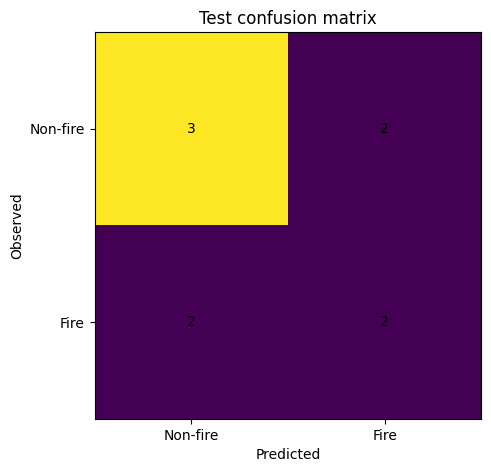

<Figure size 700x500 with 0 Axes>

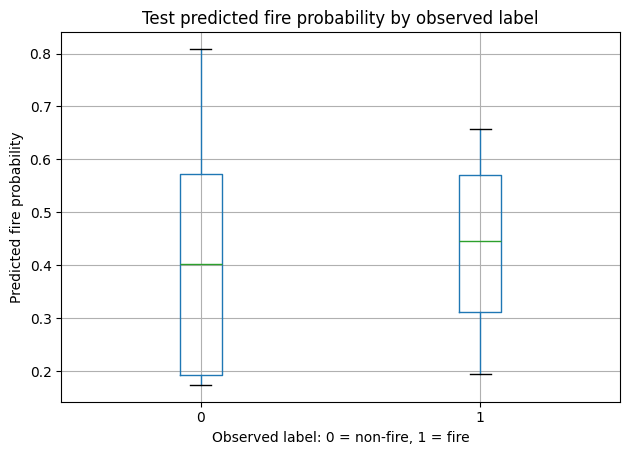

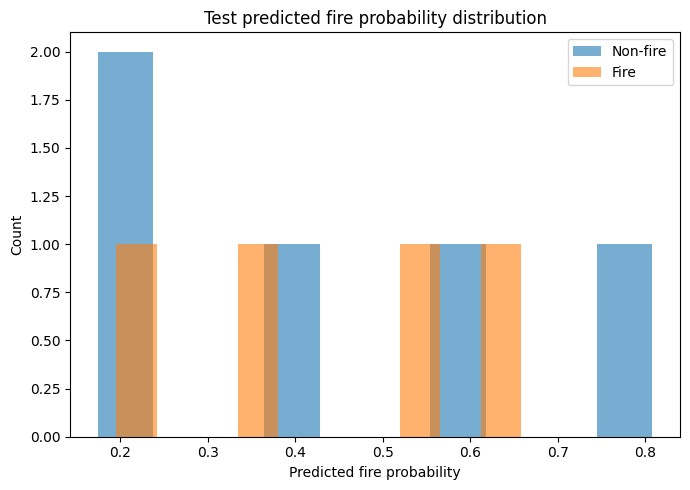

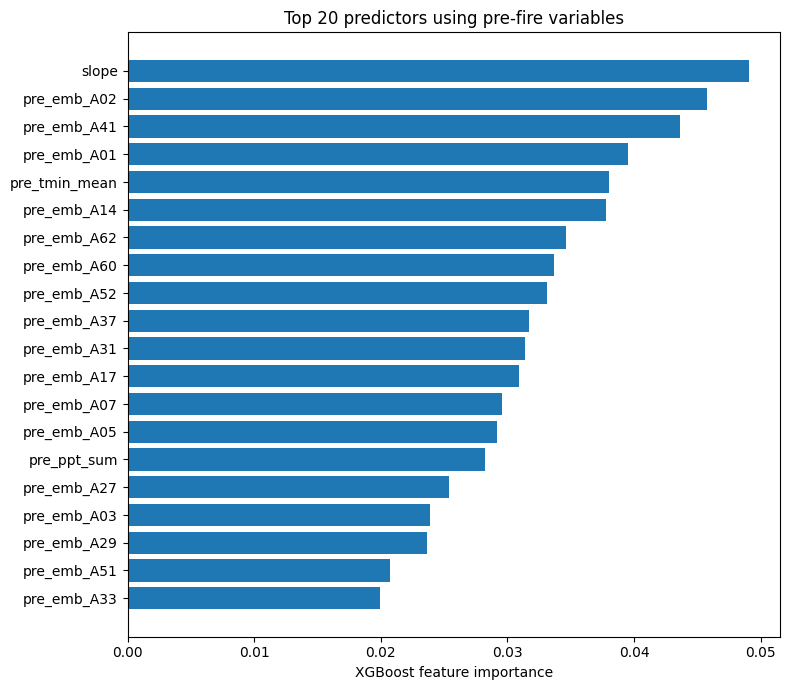

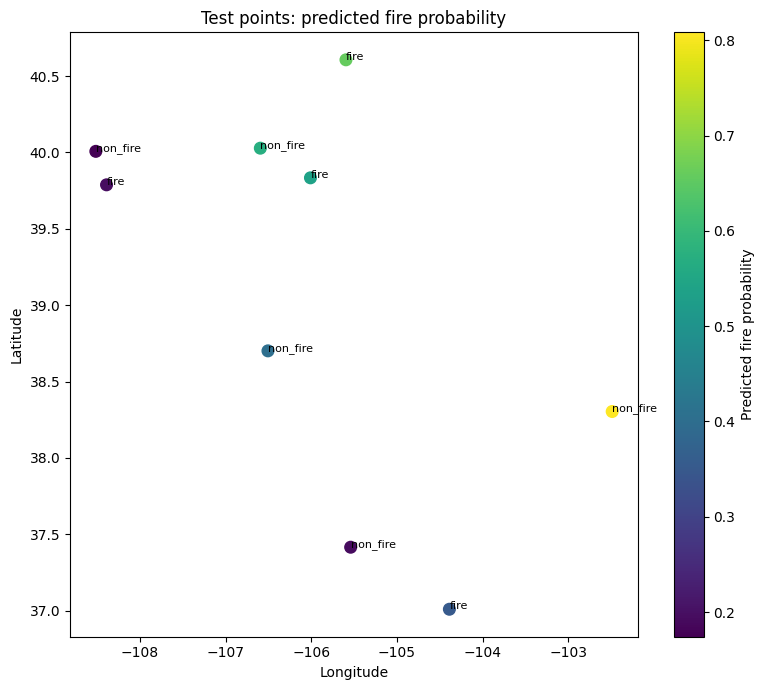


Saved:
xgb_fire_probability_prefire_model.pkl
feature_cols_prefire.pkl
xgb_feature_importance_prefire.csv
fire_nonfire_train_test_predictions_prefire.csv


In [41]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# 1. Read data
# ============================================================

df = pd.read_csv("xgboost_fire_nonfire_2020_50_clean_nonfire.csv")
df = df.replace(-9999, np.nan)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Label counts:")
print(df["label"].value_counts())

# ============================================================
# 2. Use only pre-fire embedding, pre-fire climate, and static data
# ============================================================

pre_embedding_cols = [
    c for c in df.columns
    if c.startswith("pre_emb_")
]

pre_climate_cols = [
    c for c in [
        "pre_ppt_sum",
        "pre_tmax_mean",
        "pre_tmin_mean",
        "pre_vpd_mean"
    ]
    if c in df.columns
]

static_cols = [
    c for c in [
        "elevation",
        "slope",
        "aspect",
        "longitude",
        "latitude"
    ]
    if c in df.columns
]

feature_cols = pre_embedding_cols + pre_climate_cols + static_cols

X = (
    df[feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

y = df["label"].astype(int)

print("Pre-fire embedding columns:", len(pre_embedding_cols))
print("Pre-fire climate columns:", len(pre_climate_cols))
print("Static columns:", len(static_cols))
print("Total predictors:", len(feature_cols))

# ============================================================
# 3. Train/test split: 80% train, 20% test
# ============================================================

X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X,
    y,
    df,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training label counts:")
print(y_train.value_counts())
print("Testing label counts:")
print(y_test.value_counts())

# ============================================================
# 4. XGBoost classifier
# ============================================================

clf = XGBClassifier(
    n_estimators=150,
    learning_rate=0.04,
    max_depth=2,
    min_child_weight=1,
    subsample=0.85,
    colsample_bytree=0.85,
    eval_metric="logloss",
    random_state=42
)

clf.fit(X_train, y_train)

# ============================================================
# 5. Predictions and diagnostics
# ============================================================

train_prob = clf.predict_proba(X_train)[:, 1]
test_prob = clf.predict_proba(X_test)[:, 1]

train_pred = (train_prob >= 0.5).astype(int)
test_pred = (test_prob >= 0.5).astype(int)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

train_auc = roc_auc_score(y_train, train_prob)
test_auc = roc_auc_score(y_test, test_prob)

print("\nModel diagnostics")
print("-----------------")
print("Training accuracy:", round(train_acc, 3))
print("Testing accuracy:", round(test_acc, 3))
print("Training ROC AUC:", round(train_auc, 3))
print("Testing ROC AUC:", round(test_auc, 3))
print("Testing precision:", round(precision_score(y_test, test_pred), 3))
print("Testing recall:", round(recall_score(y_test, test_pred), 3))
print("Testing F1:", round(f1_score(y_test, test_pred), 3))

print("\nTesting classification report:")
print(classification_report(y_test, test_pred, target_names=["non_fire", "fire"]))

# ============================================================
# 6. Save predictions back to dataframes
# ============================================================

df_train = df_train.copy()
df_test = df_test.copy()

df_train["set"] = "train"
df_test["set"] = "test"

df_train["pred_fire_probability"] = train_prob
df_test["pred_fire_probability"] = test_prob

df_train["pred_label"] = train_pred
df_test["pred_label"] = test_pred

df_pred = pd.concat([df_train, df_test], axis=0)

# ============================================================
# 7. Feature importance
# ============================================================

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": clf.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 20 important predictors:")
print(importance.head(20))

# ============================================================
# 8. Visualizations
# ============================================================

# Test confusion matrix
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5, 5))
plt.imshow(cm)
plt.title("Test confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Observed")
plt.xticks([0, 1], ["Non-fire", "Fire"])
plt.yticks([0, 1], ["Non-fire", "Fire"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()
# ============================================================
# Create output folder for figures
# ============================================================

import os

fig_dir = "rf_figures"

os.makedirs(fig_dir, exist_ok=True)

# Predicted probability by observed class, test only
plt.figure(figsize=(7, 5))
df_test.boxplot(column="pred_fire_probability", by="label")
plt.title("Test predicted fire probability by observed label")
plt.suptitle("")
plt.xlabel("Observed label: 0 = non-fire, 1 = fire")
plt.ylabel("Predicted fire probability")
plt.tight_layout()
plt.show()

# ============================================================
# Create output folder for figures
# ============================================================

import os

fig_dir = "rf_figures"

os.makedirs(fig_dir, exist_ok=True)

# Histogram of test probabilities
plt.figure(figsize=(7, 5))
plt.hist(df_test.loc[df_test["label"] == 0, "pred_fire_probability"], alpha=0.6, label="Non-fire")
plt.hist(df_test.loc[df_test["label"] == 1, "pred_fire_probability"], alpha=0.6, label="Fire")
plt.xlabel("Predicted fire probability")
plt.ylabel("Count")
plt.title("Test predicted fire probability distribution")
plt.legend()
plt.tight_layout()
plt.show()
# ============================================================
# Create output folder for figures
# ============================================================

import os

fig_dir = "rf_figures"

os.makedirs(fig_dir, exist_ok=True)

# Top 20 feature importance
top_imp = importance.head(20).sort_values("importance")

plt.figure(figsize=(8, 7))
plt.barh(top_imp["feature"], top_imp["importance"])
plt.xlabel("XGBoost feature importance")
plt.title("Top 20 predictors using pre-fire variables")
plt.tight_layout()
plt.show()


# # Spatial scatter for test set
# plt.figure(figsize=(7, 6))
# plt.scatter(
#     df_test["longitude"],
#     df_test["latitude"],
#     c=df_test["pred_fire_probability"],
#     s=70
# )
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.title("Test points: predicted fire probability")
# plt.colorbar(label="Predicted fire probability")
# plt.tight_layout()
# plt.show()


# Spatial scatter for test set with labels

plt.figure(figsize=(8, 7))

scatter = plt.scatter(
    df_test["longitude"],
    df_test["latitude"],
    c=df_test["pred_fire_probability"],
    s=70
)

# Add point labels using sample_type
for _, row in df_test.iterrows():
    plt.text(
        row["longitude"],
        row["latitude"],
        row["sample_type"],   # fire / non_fire
        fontsize=8
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Test points: predicted fire probability")

plt.colorbar(scatter, label="Predicted fire probability")

plt.tight_layout()
plt.show()

# ============================================================
# Create output folder for figures
# ============================================================

import os

fig_dir = "rf_figures"

os.makedirs(fig_dir, exist_ok=True)
# ============================================================
# 9. Save outputs
# ============================================================

joblib.dump(clf, "xgb_fire_probability_prefire_model.pkl")
joblib.dump(feature_cols, "feature_cols_prefire.pkl")

importance.to_csv("xgb_feature_importance_prefire.csv", index=False)
df_pred.to_csv("fire_nonfire_train_test_predictions_prefire.csv", index=False)

print("\nSaved:")
print("xgb_fire_probability_prefire_model.pkl")
print("feature_cols_prefire.pkl")
print("xgb_feature_importance_prefire.csv")
print("fire_nonfire_train_test_predictions_prefire.csv")

# Random forest

Rows: 42
Columns: 210
Label counts:
label
1    21
0    21
Name: count, dtype: int64
Pre-fire embedding columns: 64
Pre-fire climate columns: 4
Static columns: 5
Total predictors: 73
Training rows: 33
Testing rows: 9

Random Forest diagnostics
--------------------------
Training accuracy: 1.0
Testing accuracy: 0.444
Training ROC AUC: 1.0
Testing ROC AUC: 0.55
Testing precision: 0.4
Testing recall: 0.5
Testing F1: 0.444

Classification report:
              precision    recall  f1-score   support

    non_fire       0.50      0.40      0.44         5
        fire       0.40      0.50      0.44         4

    accuracy                           0.44         9
   macro avg       0.45      0.45      0.44         9
weighted avg       0.46      0.44      0.44         9


Top 20 important predictors:
          feature  importance
52    pre_emb_A52    0.054578
3     pre_emb_A03    0.041547
60    pre_emb_A60    0.038523
66  pre_tmin_mean    0.033544
21    pre_emb_A21    0.026398
54    pre_emb_A54

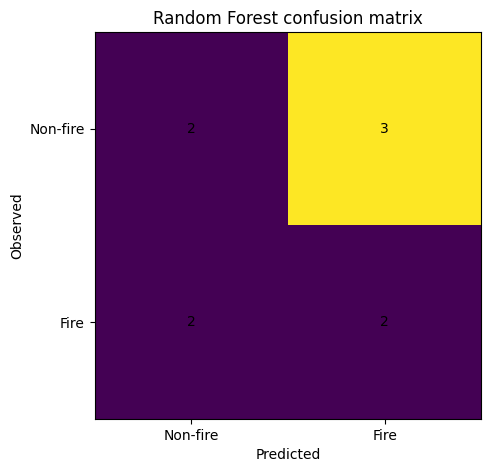

<Figure size 700x500 with 0 Axes>

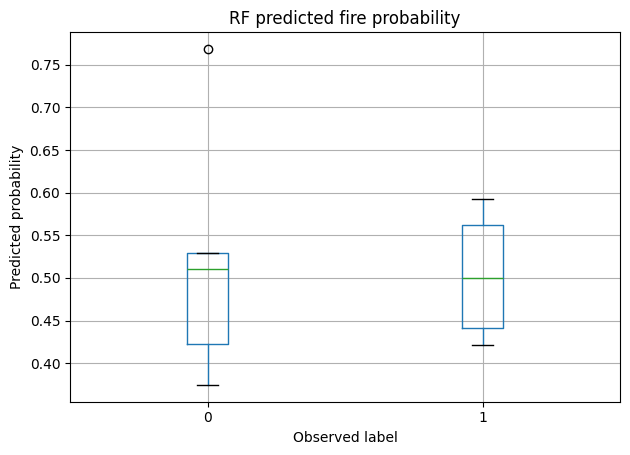

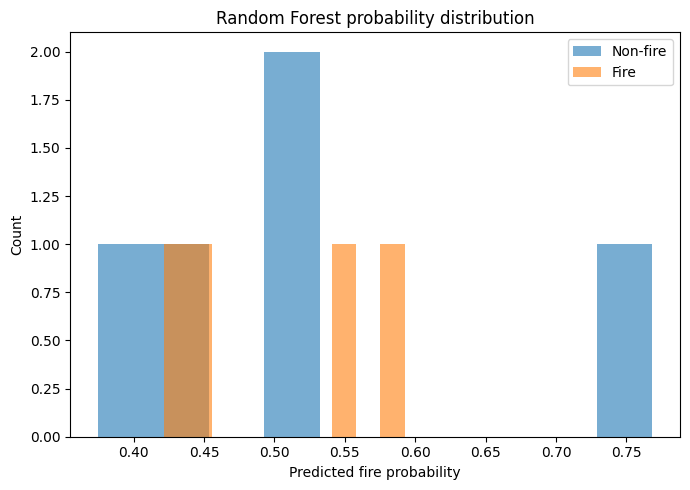

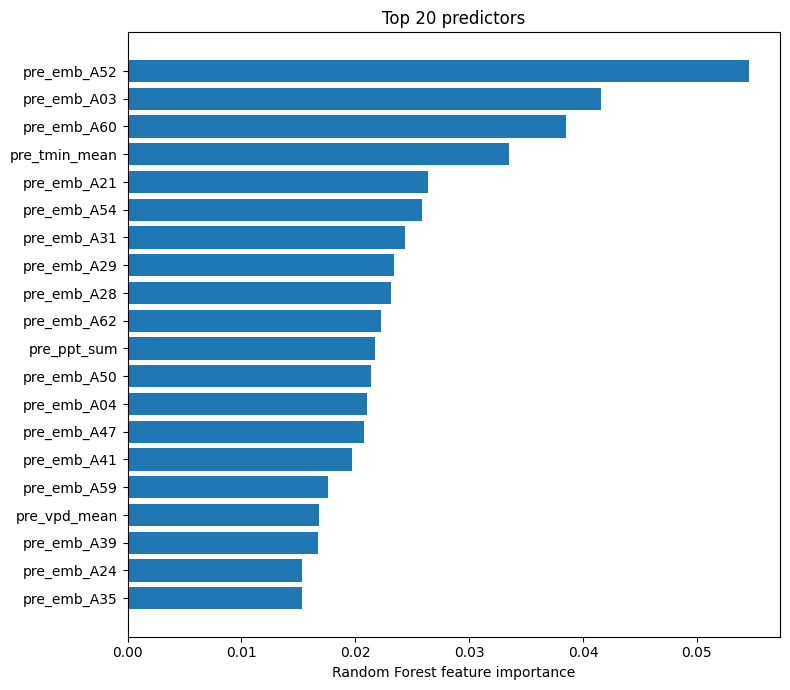

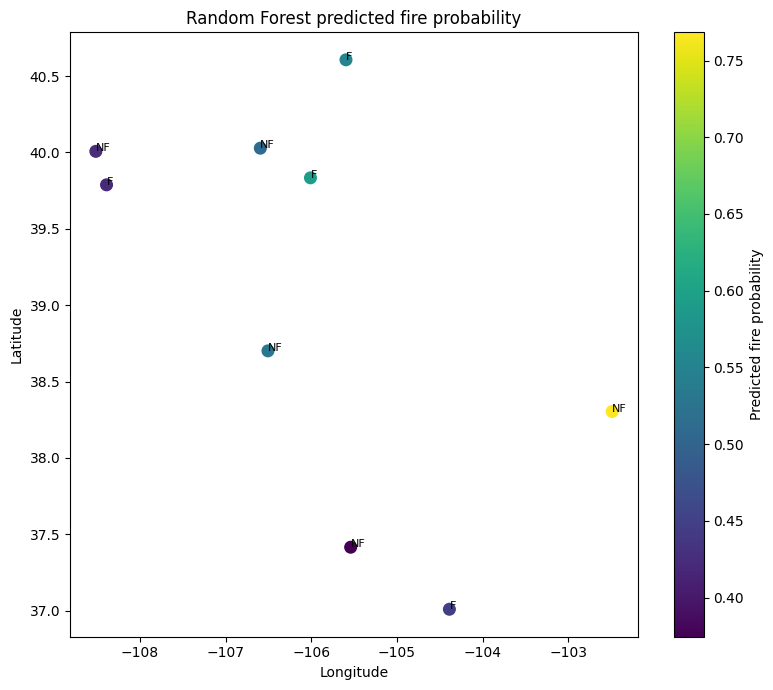


Saved:
rf_fire_probability_prefire_model.pkl
rf_feature_cols_prefire.pkl
rf_feature_importance_prefire.csv
rf_fire_nonfire_train_test_predictions.csv


In [42]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# 1. Read data
# ============================================================

df = pd.read_csv("xgboost_fire_nonfire_2020_50_clean_nonfire.csv")

df = df.replace(-9999, np.nan)

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("Label counts:")
print(df["label"].value_counts())


# ============================================================
# 2. Use only pre-fire predictors
# ============================================================

pre_embedding_cols = [
    c for c in df.columns
    if c.startswith("pre_emb_")
]

pre_climate_cols = [
    c for c in [
        "pre_ppt_sum",
        "pre_tmax_mean",
        "pre_tmin_mean",
        "pre_vpd_mean"
    ]
    if c in df.columns
]

static_cols = [
    c for c in [
        "elevation",
        "slope",
        "aspect",
        "longitude",
        "latitude"
    ]
    if c in df.columns
]

feature_cols = pre_embedding_cols + pre_climate_cols + static_cols

X = (
    df[feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

y = df["label"].astype(int)

print("Pre-fire embedding columns:", len(pre_embedding_cols))
print("Pre-fire climate columns:", len(pre_climate_cols))
print("Static columns:", len(static_cols))
print("Total predictors:", len(feature_cols))


# ============================================================
# 3. Train/test split
# ============================================================

X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X,
    y,
    df,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


# ============================================================
# 4. Random Forest classifier
# ============================================================

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


# ============================================================
# 5. Predictions
# ============================================================

train_prob = rf.predict_proba(X_train)[:, 1]
test_prob = rf.predict_proba(X_test)[:, 1]

train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

# Save predictions
df_train = df_train.copy()
df_test = df_test.copy()

df_train["set"] = "train"
df_test["set"] = "test"

df_train["pred_fire_probability"] = train_prob
df_test["pred_fire_probability"] = test_prob

df_train["pred_label"] = train_pred
df_test["pred_label"] = test_pred

df_pred = pd.concat([df_train, df_test], axis=0)


# ============================================================
# 6. Diagnostics
# ============================================================

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

train_auc = roc_auc_score(y_train, train_prob)
test_auc = roc_auc_score(y_test, test_prob)

precision = precision_score(y_test, test_pred)
recall = recall_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)

print("\nRandom Forest diagnostics")
print("--------------------------")

print("Training accuracy:", round(train_acc, 3))
print("Testing accuracy:", round(test_acc, 3))

print("Training ROC AUC:", round(train_auc, 3))
print("Testing ROC AUC:", round(test_auc, 3))

print("Testing precision:", round(precision, 3))
print("Testing recall:", round(recall, 3))
print("Testing F1:", round(f1, 3))

print("\nClassification report:")
print(classification_report(
    y_test,
    test_pred,
    target_names=["non_fire", "fire"]
))


# ============================================================
# 7. Feature importance
# ============================================================

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 20 important predictors:")
print(importance.head(20))


# ============================================================
# 8. Visualizations
# ============================================================

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5, 5))
plt.imshow(cm)

plt.title("Random Forest confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Observed")

plt.xticks([0, 1], ["Non-fire", "Fire"])
plt.yticks([0, 1], ["Non-fire", "Fire"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Predicted probabilities by observed class
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

df_test.boxplot(
    column="pred_fire_probability",
    by="label"
)

plt.title("RF predicted fire probability")
plt.suptitle("")

plt.xlabel("Observed label")
plt.ylabel("Predicted probability")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Histogram of probabilities
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.hist(
    df_test.loc[df_test["label"] == 0, "pred_fire_probability"],
    alpha=0.6,
    label="Non-fire"
)

plt.hist(
    df_test.loc[df_test["label"] == 1, "pred_fire_probability"],
    alpha=0.6,
    label="Fire"
)

plt.xlabel("Predicted fire probability")
plt.ylabel("Count")

plt.title("Random Forest probability distribution")

plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Top 20 feature importance
# ------------------------------------------------------------

top_imp = importance.head(20).sort_values("importance")

plt.figure(figsize=(8, 7))

plt.barh(
    top_imp["feature"],
    top_imp["importance"]
)

plt.xlabel("Random Forest feature importance")
plt.title("Top 20 predictors")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Spatial plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 7))

scatter = plt.scatter(
    df_test["longitude"],
    df_test["latitude"],
    c=df_test["pred_fire_probability"],
    s=70
)

for _, row in df_test.iterrows():

    label_txt = (
        "F" if row["sample_type"] == "fire"
        else "NF"
    )

    plt.text(
        row["longitude"],
        row["latitude"],
        label_txt,
        fontsize=8
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("Random Forest predicted fire probability")

plt.colorbar(
    scatter,
    label="Predicted fire probability"
)

plt.tight_layout()
plt.show()


# ============================================================
# 9. Save outputs
# ============================================================

joblib.dump(rf, "rf_fire_probability_prefire_model.pkl")

joblib.dump(
    feature_cols,
    "rf_feature_cols_prefire.pkl"
)

importance.to_csv(
    "rf_feature_importance_prefire.csv",
    index=False
)

df_pred.to_csv(
    "rf_fire_nonfire_train_test_predictions.csv",
    index=False
)

print("\nSaved:")
print("rf_fire_probability_prefire_model.pkl")
print("rf_feature_cols_prefire.pkl")
print("rf_feature_importance_prefire.csv")
print("rf_fire_nonfire_train_test_predictions.csv")

Rows: 40
Columns: 210
label
1    20
0    20
Name: count, dtype: int64
Embedding columns: 192
Climate columns: 8
Topography/location columns: 5
Total predictors: 205
Training accuracy: 1.0
Training ROC AUC: 1.0
No burn_area_ha column found, so area regression was skipped.
           feature  importance
12   delta_emb_A12    0.053234
82    post_emb_A18    0.032281
44   delta_emb_A44    0.028304
190    pre_emb_A62    0.024863
125   post_emb_A61    0.023710
27   delta_emb_A27    0.022294
45   delta_emb_A45    0.021735
22   delta_emb_A22    0.020459
80    post_emb_A16    0.019342
69    post_emb_A05    0.018554
19   delta_emb_A19    0.018005
115   post_emb_A51    0.017824
116   post_emb_A52    0.017348
20   delta_emb_A20    0.016796
136    pre_emb_A08    0.016589
59   delta_emb_A59    0.016454
26   delta_emb_A26    0.016172
120   post_emb_A56    0.015984
145    pre_emb_A17    0.015956
132    pre_emb_A04    0.014779


<Figure size 700x500 with 0 Axes>

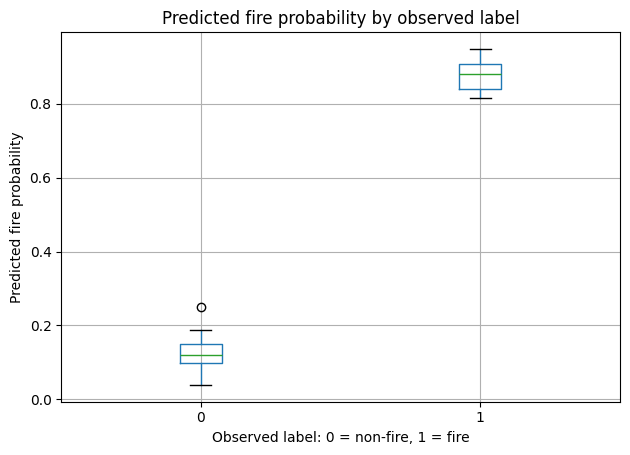

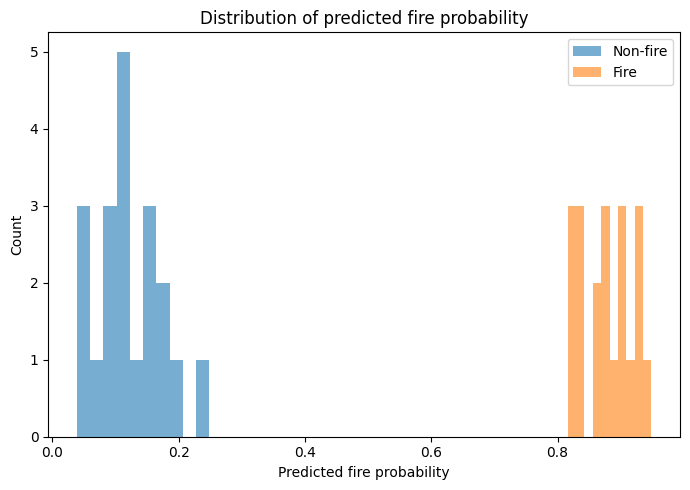

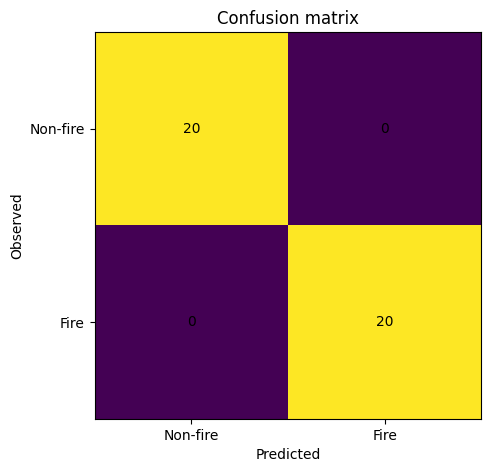

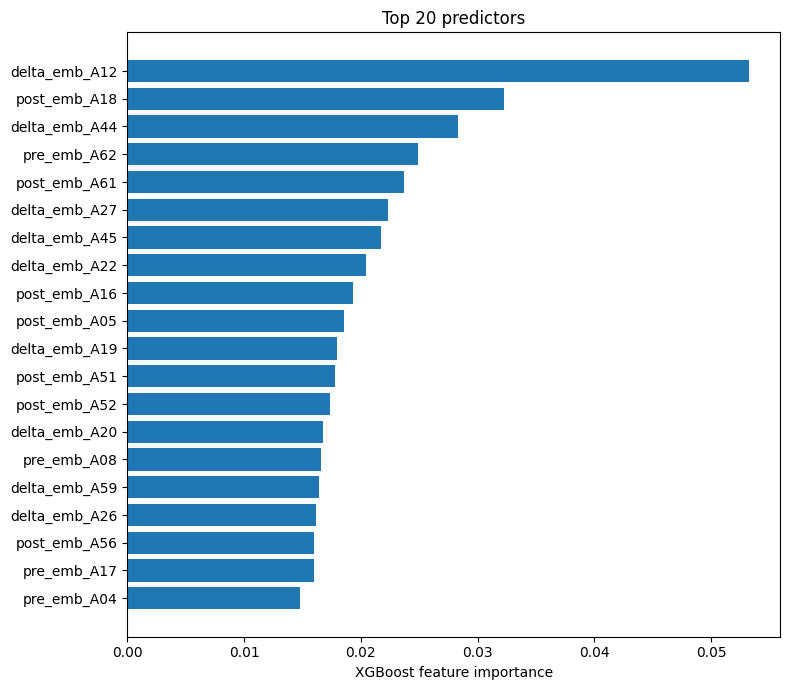

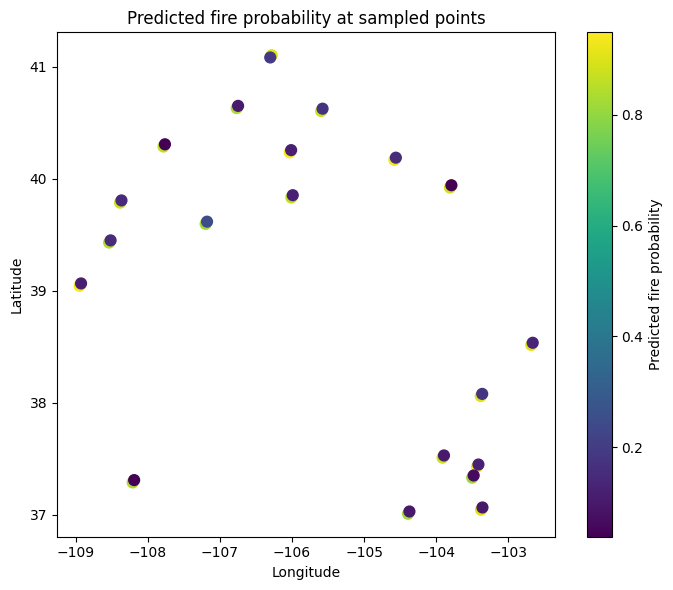

Saved:
xgb_fire_probability_model.pkl
feature_cols.pkl
xgb_feature_importance.csv
fire_nonfire_training_predictions.csv


In [30]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    mean_absolute_error,
    r2_score
)

# ============================================================
# 1. Read data
# ============================================================

df = pd.read_csv("xgboost_fire_nonfire_2020_50.csv")

# Replace no-data values if used during GEE export
df = df.replace(-9999, np.nan)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print(df["label"].value_counts())


# ============================================================
# 2. Define predictor columns
# ============================================================

embedding_cols = [
    c for c in df.columns
    if c.startswith("pre_emb_")
    or c.startswith("post_emb_")
    or c.startswith("delta_emb_")
]

climate_cols = [
    c for c in [
        "pre_ppt_sum",
        "pre_tmax_mean",
        "pre_tmin_mean",
        "pre_vpd_mean",
        "post_ppt_sum",
        "post_tmax_mean",
        "post_tmin_mean",
        "post_vpd_mean"
    ]
    if c in df.columns
]

topo_cols = [
    c for c in [
        "elevation",
        "slope",
        "aspect",
        "longitude",
        "latitude"
    ]
    if c in df.columns
]

feature_cols = embedding_cols + climate_cols + topo_cols

X = (
    df[feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

y_class = df["label"].astype(int)

print("Embedding columns:", len(embedding_cols))
print("Climate columns:", len(climate_cols))
print("Topography/location columns:", len(topo_cols))
print("Total predictors:", len(feature_cols))


# ============================================================
# 3. XGBoost classifier: fire vs non-fire
# ============================================================

clf = XGBClassifier(
    n_estimators=150,
    learning_rate=0.04,
    max_depth=2,
    min_child_weight=1,
    subsample=0.85,
    colsample_bytree=0.85,
    eval_metric="logloss",
    random_state=42
)

clf.fit(X, y_class)

df["pred_fire_probability"] = clf.predict_proba(X)[:, 1]
df["pred_label"] = (df["pred_fire_probability"] >= 0.5).astype(int)

acc = accuracy_score(y_class, df["pred_label"])

try:
    auc = roc_auc_score(y_class, df["pred_fire_probability"])
except:
    auc = np.nan

print("Training accuracy:", acc)
print("Training ROC AUC:", auc)


# ============================================================
# 4. Optional area regression
# Only runs if burn_area_ha exists
# ============================================================

if "burn_area_ha" in df.columns:
    y_area = np.log1p(df["burn_area_ha"].fillna(0))

    reg = XGBRegressor(
        n_estimators=150,
        learning_rate=0.04,
        max_depth=2,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        random_state=42
    )

    reg.fit(X, y_area)

    df["pred_area_ha"] = np.expm1(reg.predict(X))

    print("MAE affected area:",
          mean_absolute_error(df["burn_area_ha"], df["pred_area_ha"]))

    print("R2 affected area:",
          r2_score(df["burn_area_ha"], df["pred_area_ha"]))

    joblib.dump(reg, "xgb_area_model.pkl")

else:
    print("No burn_area_ha column found, so area regression was skipped.")


# ============================================================
# 5. Feature importance
# ============================================================

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": clf.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.head(20))


# ============================================================
# 6. Visualizations
# ============================================================

# Predicted fire probability by class
plt.figure(figsize=(7, 5))
df.boxplot(column="pred_fire_probability", by="label")
plt.title("Predicted fire probability by observed label")
plt.suptitle("")
plt.xlabel("Observed label: 0 = non-fire, 1 = fire")
plt.ylabel("Predicted fire probability")
plt.tight_layout()
plt.show()


# Histogram of predicted probabilities
plt.figure(figsize=(7, 5))
plt.hist(df.loc[df["label"] == 0, "pred_fire_probability"], alpha=0.6, label="Non-fire")
plt.hist(df.loc[df["label"] == 1, "pred_fire_probability"], alpha=0.6, label="Fire")
plt.xlabel("Predicted fire probability")
plt.ylabel("Count")
plt.title("Distribution of predicted fire probability")
plt.legend()
plt.tight_layout()
plt.show()


# Confusion matrix
cm = confusion_matrix(y_class, df["pred_label"])

plt.figure(figsize=(5, 5))
plt.imshow(cm)
plt.title("Confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Observed")
plt.xticks([0, 1], ["Non-fire", "Fire"])
plt.yticks([0, 1], ["Non-fire", "Fire"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


# Top 20 feature importance
top_imp = importance.head(20).sort_values("importance")

plt.figure(figsize=(8, 7))
plt.barh(top_imp["feature"], top_imp["importance"])
plt.xlabel("XGBoost feature importance")
plt.title("Top 20 predictors")
plt.tight_layout()
plt.show()


# Optional map-style scatter
plt.figure(figsize=(7, 6))
plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["pred_fire_probability"],
    s=60
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Predicted fire probability at sampled points")
plt.colorbar(label="Predicted fire probability")
plt.tight_layout()
plt.show()


# ============================================================
# 7. Save outputs
# ============================================================

joblib.dump(clf, "xgb_fire_probability_model.pkl")
joblib.dump(feature_cols, "feature_cols.pkl")

importance.to_csv("xgb_feature_importance.csv", index=False)
df.to_csv("fire_nonfire_training_predictions.csv", index=False)

print("Saved:")
print("xgb_fire_probability_model.pkl")
print("feature_cols.pkl")
print("xgb_feature_importance.csv")
print("fire_nonfire_training_predictions.csv")

import pandas as pd
import numpy as np
import joblib

from xgboost import XGBRegressor, XGBClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, roc_auc_score

df = pd.read_csv("xgboost_fire_nonfire_2020.csv")

embedding_cols = [
    c for c in df.columns
    if c.startswith("pre_")
    or c.startswith("post_")
    or c.startswith("delta_")
]

weather_cols = [
    c for c in ["pre_vpd_mean", "pre_tmax_mean", "pre_ppt_sum	"]
    if c in df.columns
]

feature_cols = embedding_cols + weather_cols

X = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

# -----------------------------
# Model 1: fire/non-fire classifier
# -----------------------------
y_class = df["sample_type"]

clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    subsample=0.85,
    colsample_bytree=0.85,
    eval_metric="logloss",
    random_state=42
)

clf.fit(X, y_class)

df["pred_fire_probability"] = clf.predict_proba(X)[:, 1]

# -----------------------------
# Model 2: affected-area regression
# Non-fire locations have area = 0
# -----------------------------
y_area = np.log1p(df["burn_area_ha"])

reg = XGBRegressor(
    n_estimators=120,
    learning_rate=0.05,
    max_depth=2,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="reg:squarederror",
    random_state=42
)

reg.fit(X, y_area)

df["pred_area_ha"] = np.expm1(reg.predict(X))

print("Training rows:", len(df))
print("Embedding columns:", len(embedding_cols))
print("Mean predicted fire probability:", df["pred_fire_probability"].mean())
print("MAE affected area:", mean_absolute_error(df["burn_area_ha"], df["pred_area_ha"]))

joblib.dump(clf, "xgb_fire_probability_model.pkl")
joblib.dump(reg, "xgb_area_model.pkl")
joblib.dump(feature_cols, "feature_cols.pkl")

df.to_csv("fire_nonfire_training_predictions.csv", index=False)

print("Saved models and predictions.")

# XGBOOST

In [ ]:
import joblib
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("CO_2020_MTBS_20_AEF_GRIDMET_training_table.csv")
df = df.dropna(subset=["burn_area_ha"]).copy()

df["log_area"] = np.log1p(df["burn_area_ha"])

feature_cols = [
    c for c in df.columns
    if c.startswith("before_")
    or c.startswith("after_")
    or c.startswith("delta_")
]

feature_cols += [
    c for c in ["vpd_fire_day", "vpd_7day", "tmmx_7day", "pr_7day"]
    if c in df.columns
]

X = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["log_area"]

model = XGBRegressor(
    n_estimators=120,
    learning_rate=0.05,
    max_depth=2,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="reg:squarederror",
    random_state=42
)

loo = LeaveOneOut()
pred_log = cross_val_predict(model, X, y, cv=loo)
pred_area = np.expm1(pred_log)

print("Toy model performance")
print(f"MAE  : {mean_absolute_error(df['burn_area_ha'], pred_area):,.2f} ha")
print(f"RMSE : {mean_squared_error(df['burn_area_ha'], pred_area, squared=False):,.2f} ha")
print(f"R2   : {r2_score(df['burn_area_ha'], pred_area):.3f}")

df["cv_pred_area_ha"] = pred_area

model.fit(X, y)

joblib.dump(model, "xgb_fire_area_toy.pkl")
joblib.dump(feature_cols, "feature_cols.pkl")
df.to_csv("training_with_predictions.csv", index=False)

print("Saved model and training outputs.")

# User interaction

In [ ]:
import ee
import joblib
import numpy as np
import pandas as pd
import streamlit as st

ee.Initialize()

st.set_page_config(
    page_title="Embedding-informed Fire Digital Twin",
    layout="wide"
)

st.title("Embedding-informed fire digital twin demo")

model = joblib.load("xgb_fire_area_toy.pkl")
feature_cols = joblib.load("feature_cols.pkl")
training_df = pd.read_csv("training_with_predictions.csv")

emb = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")

LATEST_EMBEDDING_YEAR = 2024  # change when newer annual embedding is available
BASELINE_YEAR = 2019

def get_embedding_at_location(lon, lat, buffer_m, year, prefix):
    point = ee.Geometry.Point([lon, lat])
    region = point.buffer(buffer_m)

    img = emb.filterDate(f"{year}-01-01", f"{year}-12-31").first()

    vals = img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=30,
        maxPixels=1e9,
        bestEffort=True
    ).getInfo()

    return {f"{prefix}_{k}": v for k, v in vals.items()}

def build_new_location_row(lon, lat, buffer_m, user_vpd):
    before = get_embedding_at_location(
        lon, lat, buffer_m, BASELINE_YEAR, "before"
    )

    current = get_embedding_at_location(
        lon, lat, buffer_m, LATEST_EMBEDDING_YEAR, "after"
    )

    row = {}
    row.update(before)
    row.update(current)

    # Delta embedding
    before_keys = [k for k in row.keys() if k.startswith("before_")]

    for bk in before_keys:
        band = bk.replace("before_", "")
        ak = f"after_{band}"
        dk = f"delta_{band}"

        if ak in row:
            row[dk] = row[ak] - row[bk]

    # User scenario weather
    row["vpd_fire_day"] = user_vpd
    row["vpd_7day"] = user_vpd

    # Simple defaults for demo if model expects them
    row["tmmx_7day"] = 300
    row["pr_7day"] = 0

    out = pd.DataFrame([row])

    for col in feature_cols:
        if col not in out.columns:
            out[col] = 0

    return out[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

def predict_area(X):
    pred_log = model.predict(X)[0]
    return np.expm1(pred_log)

mode = st.sidebar.radio(
    "Prediction mode",
    ["Existing demo fire", "New user location"]
)

user_vpd = st.sidebar.slider(
    "Current / scenario VPD",
    min_value=0.0,
    max_value=8.0,
    value=2.5,
    step=0.1
)

if mode == "Existing demo fire":
    fire_index = st.sidebar.selectbox(
        "Select training/demo fire",
        training_df.index.tolist()
    )

    row = training_df.loc[[fire_index]].copy()

    if "vpd_7day" in row.columns:
        row["vpd_7day"] = user_vpd
    if "vpd_fire_day" in row.columns:
        row["vpd_fire_day"] = user_vpd

    X = row[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    pred_area = predict_area(X)

    observed = row["burn_area_ha"].iloc[0]

    col1, col2 = st.columns(2)
    col1.metric("Observed burned area", f"{observed:,.1f} ha")
    col2.metric("Scenario predicted affected area", f"{pred_area:,.1f} ha")

    st.dataframe(row[["burn_area_ha", "vpd_7day", "vpd_fire_day"]])

else:
    lon = st.sidebar.number_input("Longitude", value=-105.25, format="%.6f")
    lat = st.sidebar.number_input("Latitude", value=39.50, format="%.6f")
    buffer_m = st.sidebar.slider(
        "Prediction buffer radius around location",
        min_value=250,
        max_value=5000,
        value=1000,
        step=250
    )

    run = st.sidebar.button("Run new-location digital twin")

    if run:
        with st.spinner("Querying Earth Engine embedding and running model..."):
            X_new = build_new_location_row(
                lon=lon,
                lat=lat,
                buffer_m=buffer_m,
                user_vpd=user_vpd
            )

            pred_area = predict_area(X_new)

        st.subheader("New-location prediction")

        col1, col2, col3 = st.columns(3)
        col1.metric("Predicted affected area", f"{pred_area:,.1f} ha")
        col2.metric("Scenario VPD", f"{user_vpd:.2f}")
        col3.metric("Buffer radius", f"{buffer_m:,} m")

        st.write(
            "This uses the most recent annual embedding as a current-condition proxy "
            "and combines it with the user-provided VPD scenario."
        )

        st.dataframe(X_new)

        st.download_button(
            "Download scenario input/output",
            X_new.assign(predicted_area_ha=pred_area).to_csv(index=False),
            "new_location_digital_twin_prediction.csv",
            "text/csv"
        )
    else:
        st.info("Enter lon/lat and VPD, then run the new-location prediction.")